# Final Homework — Payment Analysis for Open Banking

In [100]:
# ============================================================
# Section 0 — Setup, Load & Initial Inspection
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

# Display settings for easier notebook reading
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# File path
DATA_PATH = Path("truelayer_analytics_test_data_set.csv")

# Load data
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Make sure the CSV is saved in the same folder as this notebook."
    )

df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)

display(df_raw.head())
df_raw.info()

Dataset loaded successfully.
Shape: (500000, 20)


,id,bank_id,currency,status,api_version,failure_reason,failure_stage,customer_id,vertical,connectivity_type,amount_in_currency,country_id,createdat_ts,lastupdatedat_ts,initiated_at,executed_at,failed_at,authorizing_at,authorized_at,settled_at
0,3c6646ef17a52ac2e35fdb6a15aa44db6d85985b,b5ab8f51d35b64af079485e5bbbc335213f3a0ae,CAD,Executed,v3,NaN,NaN,365a3d703f257f52adde00af51c7f4897a6f9c6a,vertical 2,type 8,28.00,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2010-02-10 06:00:06.452249,2010-02-10 06:00:14.766862,2010-02-10 06:00:06.452249,2010-02-10 06:00:14.766862,NaN,2010-02-10 06:00:06.452249,2010-02-10 06:00:06.452249,NaN
1,6c3e58befae5a4880c62c54bdffe7243ab7b66cc,34a0061ba48d1c2810cd930dd69d42482ca92d85,CAD,Executed,v3,NaN,NaN,365a3d703f257f52adde00af51c7f4897a6f9c6a,vertical 2,type 8,18.00,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2010-01-12 06:00:17.890703,2010-01-12 06:00:22.517782,2010-01-12 06:00:17.890703,2010-01-12 06:00:22.517782,NaN,2010-01-12 06:00:17.890703,2010-01-12 06:00:17.890703,NaN
2,b2ee452081f287aa12f0efbd05c278edd332def9,660054a4565377c6e43ff7709abf56d8494ba604,CAD,Executed,v3,NaN,NaN,365a3d703f257f52adde00af51c7f4897a6f9c6a,vertical 2,type 8,28.50,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2010-02-10 07:20:57.816799,2010-02-10 07:21:04.284348,2010-02-10 07:20:57.816799,2010-02-10 07:21:04.284348,NaN,2010-02-10 07:20:57.816799,2010-02-10 07:20:57.816799,NaN
3,5aa68c655e0ca1e57bcf4a70c269151811e3ee77,660054a4565377c6e43ff7709abf56d8494ba604,CAD,Executed,v3,NaN,NaN,365a3d703f257f52adde00af51c7f4897a6f9c6a,vertical 2,type 8,16.00,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2010-02-10 06:00:20.172570,2010-02-10 06:00:25.549863,2010-02-10 06:00:20.172570,2010-02-10 06:00:25.549863,NaN,2010-02-10 06:00:20.172570,2010-02-10 06:00:20.172570,NaN
4,1d72b60adefab1066d7421d72a2c3abb3d558544,0090e57640ed78b0c16ac4606a6773769545bb17,CAD,Executed,v3,NaN,NaN,64c370a753b1db282770cdbf2aba5434a3185b3d,vertical 2,type 8,5.00,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2009-08-14 13:42:02.939891,2009-08-14 13:42:54.515245,2009-08-14 13:42:09.978416,2009-08-14 13:42:54.515245,NaN,2009-08-14 13:42:03.699860,2009-08-14 13:42:52.858713,2009-08-14 13:42:54.515245


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  500000 non-null  object 
 1   bank_id             500000 non-null  object 
 2   currency            500000 non-null  object 
 3   status              500000 non-null  object 
 4   api_version         500000 non-null  object 
 5   failure_reason      44628 non-null   object 
 6   failure_stage       44628 non-null   object 
 7   customer_id         500000 non-null  object 
 8   vertical            499988 non-null  object 
 9   connectivity_type   483695 non-null  object 
 10  amount_in_currency  500000 non-null  float64
 11  country_id          500000 non-null  object 
 12  createdat_ts        500000 non-null  object 
 13  lastupdatedat_ts    500000 non-null  object 
 14  initiated_at        237284 non-null  object 
 15  executed_at         377876 non-nul

In [101]:
# Overview of columns, data types, missing values, and unique values

column_overview = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "non_null_count": df_raw.notna().sum().values,
    "null_count": df_raw.isna().sum().values,
    "null_pct": (df_raw.isna().mean() * 100).round(2).values,
    "unique_values": df_raw.nunique(dropna=True).values
})

display(column_overview)

,column,dtype,non_null_count,null_count,null_pct,unique_values
0,id,object,500000,0,0.00,500000
1,bank_id,object,500000,0,0.00,203
2,currency,object,500000,0,0.00,4
3,status,object,500000,0,0.00,13
4,api_version,object,500000,0,0.00,3
5,failure_reason,object,44628,455372,91.07,20
6,failure_stage,object,44628,455372,91.07,5
7,customer_id,object,500000,0,0.00,173
8,vertical,object,499988,12,0.00,5
9,connectivity_type,object,483695,16305,3.26,6


In [102]:
# Check availability of fields mentioned or implied by the homework instructions

expected_columns = [
    "id",
    "bank_id",
    "bank_name",
    "bank_type",
    "merchant_id",
    "merchant_plan",
    "customer_id",
    "user_id",
    "vertical",
    "connectivity_type",
    "currency",
    "country_id",
    "status",
    "api_version",
    "failure_reason",
    "failure_stage",
    "amount_in_currency",
    "createdat_ts",
    "lastupdatedat_ts",
    "initiated_at",
    "authorizing_at",
    "authorized_at",
    "executed_at",
    "failed_at",
    "settled_at"
]

column_check = pd.DataFrame({
    "column": expected_columns,
    "present_in_combined_csv": [col in df_raw.columns for col in expected_columns]
})

display(column_check)

missing_expected_columns = column_check.loc[
    ~column_check["present_in_combined_csv"], 
    "column"
].tolist()

print("Missing expected fields:")
print(missing_expected_columns)

,column,present_in_combined_csv
0,id,True
1,bank_id,True
2,bank_name,False
3,bank_type,False
4,merchant_id,False
5,merchant_plan,False
6,customer_id,True
7,user_id,False
8,vertical,True
9,connectivity_type,True


Missing expected fields:
['bank_name', 'bank_type', 'merchant_id', 'merchant_plan', 'user_id']


The combined dataset contains the core payment-level fields required for most of the analysis: payment IDs, bank IDs, customer IDs, statuses, API versions, transaction amounts, lifecycle timestamps, country, vertical, and connectivity type.

The instructions pdf mention variables such as `merchant_plan`, `bank_type`, and `bank_name` which are not present in CSV, so later sections that request those exact dimensions will be adapted using the closest available fields: `vertical`, `connectivity_type`, `api_version`, `country_id`, and `bank_id`.


In [103]:
# Create working dataframe

df = df_raw.copy()

print("Working dataframe created.")
print("Shape:", df.shape)

Working dataframe created.
Shape: (500000, 20)


The working dataframe `df` has the same number of rows and columns as the raw dataset. All later transformations will be applied to `df`, while `df_raw` remains unchanged as a reference copy.


The raw `status` column contains mixed casing and several related lifecycle labels. For example, failed payments can appear as `failed`, `Failed`, or `AuthorisationFailed`.

To make later analysis consistent, we create a clean `status_clean` column. So the normalized status will be used for funnel analysis, conversion rates, failure rates, user classification, retention, and growth accounting.

In [104]:
status_counts = (
    df["status"]
    .value_counts(dropna=False)
    .rename_axis("raw_status")
    .reset_index(name="payment_count")
)

display(status_counts)

,raw_status,payment_count
0,Executed,377616
1,failed,44621
2,Initiated,29474
3,Cancelled,18798
4,New,18791
5,initiated,4576
6,Rejected,4058
7,Executing,936
8,Failed,478
9,authorized,243


In [105]:
# Create normalized status field

def clean_status(status):
    if pd.isna(status):
        return "unknown"
    
    s = str(status).strip().lower()
    
    status_mapping = {
        "new": "created",
        "submitted": "created",
        "initiated": "initiated",
        "authorizing": "authorizing",
        "authorized": "authorized",
        "executing": "executing",
        "executed": "executed",
        "failed": "failed",
        "authorisationfailed": "failed",
        "cancelled": "cancelled",
        "rejected": "rejected"
    }
    
    return status_mapping.get(s, s)

df["status_clean"] = df["status"].apply(clean_status)

status_clean_summary = (
    df.groupby(["status", "status_clean"], dropna=False)
      .size()
      .reset_index(name="payment_count")
      .sort_values("payment_count", ascending=False)
)

display(status_clean_summary)

,status,status_clean,payment_count
2,Executed,executed,377616
11,failed,failed,44621
5,Initiated,initiated,29474
1,Cancelled,cancelled,18798
6,New,created,18791
12,initiated,initiated,4576
7,Rejected,rejected,4058
3,Executing,executing,936
4,Failed,failed,478
9,authorized,authorized,243


The raw `status` field was standardized into `status_clean`.

This reduces inconsistencies caused by mixed casing and related lifecycle labels. So in our case, `failed`, `Failed`, and `AuthorisationFailed` are all treated as failed payments.

I'm using cleaned status field for conversion, funnel, failure, retention, and user lifecycle calculations.

This step converts all lifecycle timestamp columns to datetime format.

The instructions use the term `user_id`, while the dataset contains `customer_id`. so we adapted the customer_id variable for future.

In [106]:
# Convert timestamp columns to datetime

timestamp_cols = [
    "createdat_ts",
    "lastupdatedat_ts",
    "initiated_at",
    "authorizing_at",
    "authorized_at",
    "executed_at",
    "failed_at",
    "settled_at"
]

for col in timestamp_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Match instruction wording
df["user_id"] = df["customer_id"]

# Monthly fields for trend, cohort, and growth accounting analysis
df["created_month"] = df["createdat_ts"].dt.to_period("M").dt.to_timestamp()
df["executed_month"] = df["executed_at"].dt.to_period("M").dt.to_timestamp()

# Helper flags for repeated analysis
df["is_executed"] = df["status_clean"].eq("executed")
df["is_failed"] = df["status_clean"].eq("failed")
df["is_cancelled"] = df["status_clean"].eq("cancelled")
df["is_rejected"] = df["status_clean"].eq("rejected")

display(df.head())

,id,bank_id,currency,status,api_version,failure_reason,failure_stage,customer_id,vertical,connectivity_type,amount_in_currency,country_id,createdat_ts,lastupdatedat_ts,initiated_at,executed_at,failed_at,authorizing_at,authorized_at,settled_at,status_clean,user_id,created_month,executed_month,is_executed,is_failed,is_cancelled,is_rejected
0,3c6646ef17a52ac2e35fdb6a15aa44db6d85985b,b5ab8f51d35b64af079485e5bbbc335213f3a0ae,CAD,Executed,v3,NaN,NaN,365a3d703f257f52adde00af51c7f4897a6f9c6a,vertical 2,type 8,28.00,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2010-02-10 06:00:06.452249,2010-02-10 06:00:14.766862,2010-02-10 06:00:06.452249,2010-02-10 06:00:14.766862,NaT,2010-02-10 06:00:06.452249,2010-02-10 06:00:06.452249,NaT,executed,365a3d703f257f52adde00af51c7f4897a6f9c6a,2010-02-01,2010-02-01,True,False,False,False
1,6c3e58befae5a4880c62c54bdffe7243ab7b66cc,34a0061ba48d1c2810cd930dd69d42482ca92d85,CAD,Executed,v3,NaN,NaN,365a3d703f257f52adde00af51c7f4897a6f9c6a,vertical 2,type 8,18.00,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2010-01-12 06:00:17.890703,2010-01-12 06:00:22.517782,2010-01-12 06:00:17.890703,2010-01-12 06:00:22.517782,NaT,2010-01-12 06:00:17.890703,2010-01-12 06:00:17.890703,NaT,executed,365a3d703f257f52adde00af51c7f4897a6f9c6a,2010-01-01,2010-01-01,True,False,False,False
2,b2ee452081f287aa12f0efbd05c278edd332def9,660054a4565377c6e43ff7709abf56d8494ba604,CAD,Executed,v3,NaN,NaN,365a3d703f257f52adde00af51c7f4897a6f9c6a,vertical 2,type 8,28.50,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2010-02-10 07:20:57.816799,2010-02-10 07:21:04.284348,2010-02-10 07:20:57.816799,2010-02-10 07:21:04.284348,NaT,2010-02-10 07:20:57.816799,2010-02-10 07:20:57.816799,NaT,executed,365a3d703f257f52adde00af51c7f4897a6f9c6a,2010-02-01,2010-02-01,True,False,False,False
3,5aa68c655e0ca1e57bcf4a70c269151811e3ee77,660054a4565377c6e43ff7709abf56d8494ba604,CAD,Executed,v3,NaN,NaN,365a3d703f257f52adde00af51c7f4897a6f9c6a,vertical 2,type 8,16.00,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2010-02-10 06:00:20.172570,2010-02-10 06:00:25.549863,2010-02-10 06:00:20.172570,2010-02-10 06:00:25.549863,NaT,2010-02-10 06:00:20.172570,2010-02-10 06:00:20.172570,NaT,executed,365a3d703f257f52adde00af51c7f4897a6f9c6a,2010-02-01,2010-02-01,True,False,False,False
4,1d72b60adefab1066d7421d72a2c3abb3d558544,0090e57640ed78b0c16ac4606a6773769545bb17,CAD,Executed,v3,NaN,NaN,64c370a753b1db282770cdbf2aba5434a3185b3d,vertical 2,type 8,5.00,9e2b06736b477b7a924f60de14a7e329d82d6f4f,2009-08-14 13:42:02.939891,2009-08-14 13:42:54.515245,2009-08-14 13:42:09.978416,2009-08-14 13:42:54.515245,NaT,2009-08-14 13:42:03.699860,2009-08-14 13:42:52.858713,2009-08-14 13:42:54.515245,executed,64c370a753b1db282770cdbf2aba5434a3185b3d,2009-08-01,2009-08-01,True,False,False,False


In [107]:
# Section 0 validation summary

section0_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns_after_preparation",
        "date_min",
        "date_max",
        "unique_payments",
        "unique_users",
        "unique_banks",
        "unique_countries",
        "raw_status_values",
        "clean_status_values"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["createdat_ts"].min(),
        df["createdat_ts"].max(),
        df["id"].nunique(),
        df["user_id"].nunique(),
        df["bank_id"].nunique(),
        df["country_id"].nunique(),
        df["status"].nunique(dropna=False),
        df["status_clean"].nunique(dropna=False)
    ]
})

display(section0_summary)

,metric,value
0,rows,500000
1,columns_after_preparation,28
2,date_min,2004-06-02 11:38:07.496309
3,date_max,2010-02-11 00:01:05.197460
4,unique_payments,500000
5,unique_users,173
6,unique_banks,203
7,unique_countries,14
8,raw_status_values,13
9,clean_status_values,9


The dataset contains 500,000 payment records. The original file has 20 columns, and after preparation the working dataframe has 28 columns.

CSV given to us is an already-combined analytical dataset so there is no need for physical join. The main identifiers are `id`, `bank_id`, `customer_id`, `country_id`, and `api_version`. Since the instructions use `user_id`, a `user_id` column was created from `customer_id`.

Our raw `status` column contained 13 different values with mixed casing and related lifecycle labels. These were normalized into 9 clean status categories in `status_clean`, which we will be using for the analysis.

# Section 1 — Data Quality Assessment

Before looking at conversion, volume, or retention, I first check whether the dataset is reliable enough for analysis. This section focuses on missing values, lifecycle timestamp logic, and differences across API versions.

In [108]:
# Null count and null percentage by column

null_summary = (
    pd.DataFrame({
        "column": df.columns,
        "null_count": df.isna().sum().values,
        "null_pct": (df.isna().mean() * 100).round(2).values,
        "non_null_count": df.notna().sum().values
    })
    .sort_values("null_pct", ascending=False)
    .reset_index(drop=True)
)

display(null_summary)

,column,null_count,null_pct,non_null_count
0,failed_at,455372,91.07,44628
1,failure_reason,455372,91.07,44628
2,failure_stage,455372,91.07,44628
3,settled_at,426640,85.33,73360
4,authorized_at,301795,60.36,198205
5,initiated_at,262716,52.54,237284
6,authorizing_at,260673,52.13,239327
7,executed_month,122124,24.42,377876
8,executed_at,122124,24.42,377876
9,connectivity_type,16305,3.26,483695


This table shows how many values are missing in each column. The lifecycle timestamp columns are very important since payments doon't reach the same stage and failed or cancelled payments should not always have `executed_at` or `settled_at`.

In [109]:
# Focus specifically on lifecycle timestamp columns

lifecycle_cols = [
    "createdat_ts",
    "initiated_at",
    "authorizing_at",
    "authorized_at",
    "executed_at",
    "settled_at",
    "failed_at"
]

lifecycle_null_summary = (
    null_summary[null_summary["column"].isin(lifecycle_cols)]
    .sort_values("null_pct", ascending=False)
    .reset_index(drop=True)
)

display(lifecycle_null_summary)

,column,null_count,null_pct,non_null_count
0,failed_at,455372,91.07,44628
1,settled_at,426640,85.33,73360
2,authorized_at,301795,60.36,198205
3,initiated_at,262716,52.54,237284
4,authorizing_at,260673,52.13,239327
5,executed_at,122124,24.42,377876
6,createdat_ts,0,0.00,500000


## Q1.2 — Timestamp order for executed payments

For executed payments, the timestamps should follow the lifecycle order:

`createdat_ts < initiated_at < authorizing_at < authorized_at < executed_at`

HEre we check if this order is broken. These rows may indicate data issues, duplicated timestamps and some inconcistencies.

In [110]:
# Filter to executed payments

executed_payments = df[df["is_executed"]].copy()

print("Executed payments:", len(executed_payments))

Executed payments: 377616


In [111]:
# Check timestamp ordering rules for executed payments

timestamp_order_checks = {
    "created_before_initiated": executed_payments["createdat_ts"] < executed_payments["initiated_at"],
    "initiated_before_authorizing": executed_payments["initiated_at"] < executed_payments["authorizing_at"],
    "authorizing_before_authorized": executed_payments["authorizing_at"] < executed_payments["authorized_at"],
    "authorized_before_executed": executed_payments["authorized_at"] < executed_payments["executed_at"]
}

timestamp_violations = []

for rule, check in timestamp_order_checks.items():
    valid_comparison = check.fillna(False)
    violations = (~valid_comparison).sum()
    
    timestamp_violations.append({
        "rule": rule,
        "violating_rows": violations,
        "violation_pct_of_executed": round(violations / len(executed_payments) * 100, 2)
    })

timestamp_violations = pd.DataFrame(timestamp_violations)

display(timestamp_violations)

,rule,violating_rows,violation_pct_of_executed
0,created_before_initiated,215380,57.04
1,initiated_before_authorizing,377616,100.00
2,authorizing_before_authorized,215380,57.04
3,authorized_before_executed,187581,49.68


In [112]:
# Show a small sample of problematic executed payments for inspection

problem_mask = (
    ~(executed_payments["createdat_ts"] < executed_payments["initiated_at"]) |
    ~(executed_payments["initiated_at"] < executed_payments["authorizing_at"]) |
    ~(executed_payments["authorizing_at"] < executed_payments["authorized_at"]) |
    ~(executed_payments["authorized_at"] < executed_payments["executed_at"])
)

timestamp_problem_sample = executed_payments.loc[
    problem_mask,
    [
        "id",
        "status",
        "status_clean",
        "createdat_ts",
        "initiated_at",
        "authorizing_at",
        "authorized_at",
        "executed_at"
    ]
].head(10)

display(timestamp_problem_sample)

,id,status,status_clean,createdat_ts,initiated_at,authorizing_at,authorized_at,executed_at
0,3c6646ef17a52ac2e35fdb6a15aa44db6d85985b,Executed,executed,2010-02-10 06:00:06.452249,2010-02-10 06:00:06.452249,2010-02-10 06:00:06.452249,2010-02-10 06:00:06.452249,2010-02-10 06:00:14.766862
1,6c3e58befae5a4880c62c54bdffe7243ab7b66cc,Executed,executed,2010-01-12 06:00:17.890703,2010-01-12 06:00:17.890703,2010-01-12 06:00:17.890703,2010-01-12 06:00:17.890703,2010-01-12 06:00:22.517782
2,b2ee452081f287aa12f0efbd05c278edd332def9,Executed,executed,2010-02-10 07:20:57.816799,2010-02-10 07:20:57.816799,2010-02-10 07:20:57.816799,2010-02-10 07:20:57.816799,2010-02-10 07:21:04.284348
3,5aa68c655e0ca1e57bcf4a70c269151811e3ee77,Executed,executed,2010-02-10 06:00:20.172570,2010-02-10 06:00:20.172570,2010-02-10 06:00:20.172570,2010-02-10 06:00:20.172570,2010-02-10 06:00:25.549863
4,1d72b60adefab1066d7421d72a2c3abb3d558544,Executed,executed,2009-08-14 13:42:02.939891,2009-08-14 13:42:09.978416,2009-08-14 13:42:03.699860,2009-08-14 13:42:52.858713,2009-08-14 13:42:54.515245
5,bcfa97793076f65649b957dd799997ba2efaef3b,Executed,executed,2009-08-20 14:05:30.662267,2009-08-20 14:05:35.397045,2009-08-20 14:05:31.590486,2009-08-20 14:06:02.119292,2009-08-20 14:06:03.968660
7,f23ca43a1cfc1ed47ecb6c37dd352ff426644d27,Executed,executed,2010-01-19 06:00:22.670235,2010-01-19 06:00:22.670235,2010-01-19 06:00:22.670235,2010-01-19 06:00:22.670235,2010-01-19 06:00:28.520191
8,d5478919b341d23f0cba6cf31e20728e71afc257,Executed,executed,2009-10-22 15:17:17.046271,2009-10-22 15:17:23.534314,2009-10-22 15:17:18.082226,2009-10-22 15:17:56.035144,2009-10-22 15:17:56.222319
9,da1be4c92610de8116f34d30c57635b26c40af1a,Executed,executed,2010-02-05 05:06:16.494003,2010-02-05 05:06:36.935998,2010-02-05 05:06:24.631949,2010-02-05 05:07:06.656714,2010-02-05 05:07:09.448444
10,71425ba68caf05a990062959e17e9201ed0a72ee,Executed,executed,2009-12-25 15:30:47.583276,2009-12-25 15:30:54.577410,2009-12-25 15:30:50.367415,2009-12-25 15:31:27.245779,2009-12-25 15:31:29.723232


This check identifies executed payments where at least one lifecycle timestamp does not follow the expected order.  it doesnt mean that the payments are wrong but that they might beenrecorded at same time or that some lifecycle fields have been inputed differently.

## Q1.3 — Data quality by API version

Next, I compare the main payment outcomes by `api_version`. This helps show whether one version has systematically different success rates, failure rates, or missing failure reasons.


In [113]:
# API version quality summary

api_version_summary = (
    df.groupby("api_version")
      .agg(
          payment_count=("id", "count"),
          executed_count=("is_executed", "sum"),
          failed_count=("is_failed", "sum")
      )
      .reset_index()
)

api_version_summary["executed_pct"] = (
    api_version_summary["executed_count"] / api_version_summary["payment_count"] * 100
).round(2)

api_version_summary["failed_pct"] = (
    api_version_summary["failed_count"] / api_version_summary["payment_count"] * 100
).round(2)

display(api_version_summary)

,api_version,payment_count,executed_count,failed_count,executed_pct,failed_pct
0,v1,96212,68386,478,71.08,0.50
1,v2,162651,117675,206,72.35,0.13
2,v3,241137,191555,44621,79.44,18.50


In [114]:
# Among failed payments, check missing failure_reason by API version

failed_reason_summary = (
    df[df["is_failed"]]
    .groupby("api_version")
    .agg(
        failed_payment_count=("id", "count"),
        failed_with_null_reason=("failure_reason", lambda x: x.isna().sum())
    )
    .reset_index()
)

failed_reason_summary["failed_null_reason_pct"] = (
    failed_reason_summary["failed_with_null_reason"] /
    failed_reason_summary["failed_payment_count"] * 100
).round(2)

api_version_quality = api_version_summary.merge(
    failed_reason_summary,
    on="api_version",
    how="left"
)

display(api_version_quality)

,api_version,payment_count,executed_count,failed_count,executed_pct,failed_pct,failed_payment_count,failed_with_null_reason,failed_null_reason_pct
0,v1,96212,68386,478,71.08,0.50,478,478,100.00
1,v2,162651,117675,206,72.35,0.13,206,206,100.00
2,v3,241137,191555,44621,79.44,18.50,44621,0,0.00


There are clear differences between API versions.

`v3` has the largest number of payments and the highest execution rate at 79.44%, but it has a higher failure rate at 18.50% whereas, `v1` and `v2` have much lower failure rates of 0.50% and 0.13%.

The biggest data quality difference is in `failure_reason`. For `v1` and `v2`, 100% of failed payments have a missing failure reason. For `v3`, none of the failed payments have a missing failure reason.
 It s possible that earlier API versions didnt record failure reasons in the same way, and `v3` is a newer approach with failure tracking. Because of this, failure reason analysis will be interpreted mainly using `v3`, or at least with a warning that `v1` and `v2` have incomplete failure reason data.

In [115]:
# Q1.4 — Bank ID completeness in the combined dataset

bank_id_quality = pd.DataFrame({
    "metric": [
        "total_payments",
        "payments_with_null_bank_id",
        "payments_with_null_bank_id_pct",
        "unique_bank_ids"
    ],
    "value": [
        len(df),
        df["bank_id"].isna().sum(),
        round(df["bank_id"].isna().mean() * 100, 2),
        df["bank_id"].nunique()
    ]
})

display(bank_id_quality)

,metric,value
0,total_payments,"500,000.00"
1,payments_with_null_bank_id,0.00
2,payments_with_null_bank_id_pct,0.00
3,unique_bank_ids,203.00


In [116]:
# Payment count by bank_id, useful for later bank-level analysis

bank_payment_counts = (
    df.groupby("bank_id")
      .agg(payment_count=("id", "count"))
      .reset_index()
      .sort_values("payment_count", ascending=False)
)

display(bank_payment_counts.head(10))

,bank_id,payment_count
93,6cd7d8d37b110668afdca42fc0e1d366b322783e,64679
143,b5ab8f51d35b64af079485e5bbbc335213f3a0ae,62069
198,fa485aff3f9e34d55d25f78856d4a2526a5f8e6f,46359
88,6926610db1dfc17aca46a6f67789d7d6c24a7185,44917
85,660054a4565377c6e43ff7709abf56d8494ba604,36120
36,34a0061ba48d1c2810cd930dd69d42482ca92d85,36032
2,0090e57640ed78b0c16ac4606a6773769545bb17,32280
182,e8085010136a26d0ebc200ac0751b1d9d673a764,27195
146,b7308502f039e303a048625c725d4aea3380c2ac,26788
62,4d762ce64874cd49be593313e92a1e61cf74417e,10367


In [117]:
# Section 1 compact quality summary

section1_summary = pd.DataFrame({
    "check": [
        "Columns with any null values",
        "Executed payments checked for timestamp order",
        "API versions compared",
        "Bank IDs available",
        "Null bank_id percentage"
    ],
    "result": [
        (df.isna().sum() > 0).sum(),
        len(executed_payments),
        df["api_version"].nunique(),
        df["bank_id"].nunique(),
        round(df["bank_id"].isna().mean() * 100, 2)
    ]
})

display(section1_summary)

,check,result
0,Columns with any null values,11.00
1,Executed payments checked for timestamp order,"377,616.00"
2,API versions compared,3.00
3,Bank IDs available,203.00
4,Null bank_id percentage,0.00


The data quality checks show that the dataset is usable ,t here are 11 columns with some missing values, but itss expected since payment lifecycle fields only populate when a payment reaches that stage. For example, failed payments should have failure-related fields, while executed or settled payments should not always have them.

For the bank check, all payments have a `bank_id`, and in this dataset there are 203 unique banks. but in our case the original `banks.csv` reference table is not available separately so I cannot directly calculate the percentage of bank IDs missing from `banks.csv`. Also there are no null `bank_id` values.


In [118]:
# ============================================================
# Section 2 — Funnel & Conversion Analysis
# ============================================================

# 2.1  Build funnel from lifecycle timestamps

df['is_settled'] = df['settled_at'].notna()

total       = len(df)
initiated   = df['initiated_at'].notna().sum()
authorizing = df['authorizing_at'].notna().sum()
authorized  = df['authorized_at'].notna().sum()
executed    = df['is_executed'].sum()
settled     = df['is_settled'].sum()

funnel = pd.DataFrame({
    'Stage': ['Created','Initiated','Authorizing','Authorized','Executed','Settled'],
    'Count': [total, initiated, authorizing, authorized, executed, settled]
})

funnel['drop_off_pct'] = (
    (funnel['Count'].shift(1) - funnel['Count']) / funnel['Count'].shift(1) * 100
).fillna(0).round(2)

funnel['cumulative_pct'] = (funnel['Count'] / total * 100).round(2)

print(funnel.to_string(index=False))

      Stage  Count  drop_off_pct  cumulative_pct
    Created 500000          0.00          100.00
  Initiated 237284         52.54           47.46
Authorizing 239327         -0.86           47.87
 Authorized 198205         17.18           39.64
   Executed 377616        -90.52           75.52
    Settled  73360         80.57           14.67


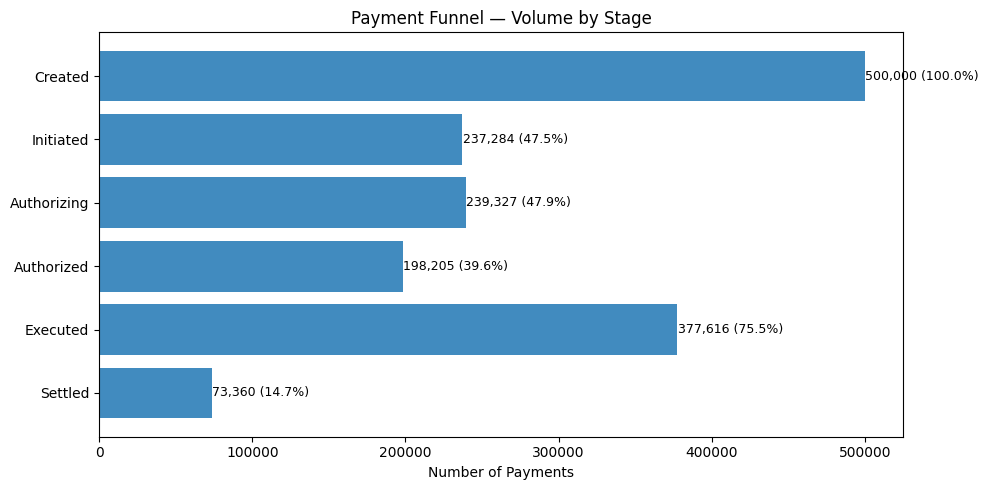

In [119]:
# 2.2  Funnel chart

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    funnel['Stage'][::-1],
    funnel['Count'][::-1],
    alpha=0.85
)

for bar, row in zip(bars, funnel[::-1].itertuples()):
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f'{row.Count:,} ({row.cumulative_pct:.1f}%)',
        va='center',
        fontsize=9
    )

ax.set_title('Payment Funnel — Volume by Stage')
ax.set_xlabel('Number of Payments')
plt.tight_layout()
plt.show()

#### Q2.1 Answer

The funnel starts with 500,000 payments. Here 47.5% have an `initiated_at` timestamp, and 47.9% have an `authorizing_at` timestamp. The authorized stage is lower at 39.6% of created payments.

The executed stage is higher than the authorized stage = 377,616 executed payments and 75.5% of all created payments. This means the lifecycle timestamps are not perfectly sequential in the dataset: many payments are marked as executed even when earlier authorization timestamps are missing.

Only 73,360 payments, or 14.7% of created payments have a settlement timestamp. Which could mean that settlement is tracked separately from execution, and not every executed payment has a recorded `settled_at` value in the dataset.

In [120]:
# 2.2  E2E conversion rate by key dimensions

def conversion_by_dimension(data, dim):
    summary = (
        data.groupby(dim, dropna=False)
            .agg(
                payments=('id', 'count'),
                executed=('is_executed', 'sum')
            )
            .reset_index()
    )
    
    summary['conversion_pct'] = (
        summary['executed'] / summary['payments'] * 100
    ).round(2)
    
    return summary.sort_values('conversion_pct', ascending=False)


dimensions = [
    'vertical',
    'merchant_plan',
    'connectivity_type',
    'bank_type',
    'api_version'
]

available_dims = [d for d in dimensions if d in df.columns]
missing_dims = [d for d in dimensions if d not in df.columns]

print("Available dimensions:", available_dims)
print("Missing dimensions:", missing_dims)

Available dimensions: ['vertical', 'connectivity_type', 'api_version']
Missing dimensions: ['merchant_plan', 'bank_type']


In [121]:
# Conversion by vertical

vertical_conversion = conversion_by_dimension(df, 'vertical')

print(vertical_conversion.to_string(index=False))

  vertical  payments  executed  conversion_pct
vertical 5    139259    112450           80.75
vertical 4     11607      9237           79.58
vertical 2    347996    255257           73.35
vertical 1       580       363           62.59
vertical 3       546       306           56.04
       NaN        12         3           25.00


In [122]:
# Conversion by connectivity type

connectivity_conversion = conversion_by_dimension(df, 'connectivity_type')

print(connectivity_conversion.to_string(index=False))

connectivity_type  payments  executed  conversion_pct
           type 8    451995    352869           78.07
           type 3      2304      1780           77.26
           type 7      4880      3123           64.00
           type 1      9628      5986           62.17
           type 6      8981      5327           59.31
           type 2      5907      2580           43.68
              NaN     16305      5951           36.50


In [123]:
# Conversion by API version

api_conversion = conversion_by_dimension(df, 'api_version')

print(api_conversion.to_string(index=False))

api_version  payments  executed  conversion_pct
         v3    241137    191555           79.44
         v2    162651    117675           72.35
         v1     96212     68386           71.08


#### Q2.2 Answer

conversion breakdowns are calculated for `vertical`, `connectivity_type`, and `api_version`. the combined dataset does not include `merchant_plan` or `bank_type`, so I omitted them/

Conversion differs noticeably by segment. By vertical, `vertical 5` has the highest conversion rate at 80.75%, followed by `vertical 4` at 79.58%. `vertical 3` and the rows with missing vertical values have much lower conversion, although their payment counts are small.

By connectivity type, `type 8` has the strongest conversion rate at 78.07% and also the largest payment volume. Missing connectivity type has the weakest conversion rate at 36.50%, which could mean  missing connectivity information is due to weaker payment performance or incomplete records.

By API version, conversion improves from `v1` to `v3`: `v1` converts at 71.08%, `v2` at 72.35%, and `v3` at 79.44%.  `v3` performs better on end-to-end execution, but when checking earlier data quality, it showed that `v3` has a much higher recorded failure rate.

In [124]:
# 2.3  Monthly E2E conversion with 3-month rolling average

monthly = (
    df.groupby('created_month')
      .agg(
          payments=('id', 'count'),
          executed=('is_executed', 'sum')
      )
      .reset_index()
)

monthly['conversion_pct'] = (
    monthly['executed'] / monthly['payments'] * 100
).round(2)

monthly['conversion_3m_avg'] = (
    monthly['conversion_pct']
    .rolling(window=3, min_periods=1)
    .mean()
    .round(2)
)

print(monthly.head().to_string(index=False))
print(monthly.tail().to_string(index=False))

created_month  payments  executed  conversion_pct  conversion_3m_avg
   2004-06-01         1         0            0.00               0.00
   2004-09-01         3         0            0.00               0.00
   2004-10-01         1         0            0.00               0.00
   2004-11-01         1         0            0.00               0.00
   2005-01-01         4         0            0.00               0.00
created_month  payments  executed  conversion_pct  conversion_3m_avg
   2009-10-01     27189     21324           78.43              78.61
   2009-11-01     30043     23571           78.46              78.76
   2009-12-01     32653     26042           79.75              78.88
   2010-01-01     34580     27775           80.32              79.51
   2010-02-01     12211      9836           80.55              80.21


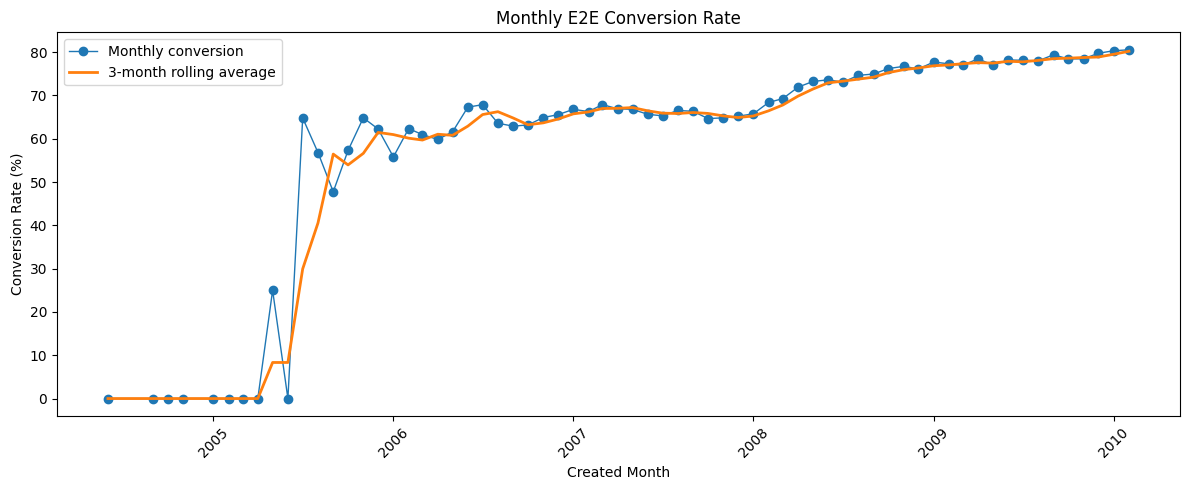

In [125]:
# Plot monthly conversion and 3-month rolling average

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly['created_month'],
    monthly['conversion_pct'],
    marker='o',
    linewidth=1,
    label='Monthly conversion'
)

ax.plot(
    monthly['created_month'],
    monthly['conversion_3m_avg'],
    linewidth=2,
    label='3-month rolling average'
)

ax.set_title('Monthly E2E Conversion Rate')
ax.set_xlabel('Created Month')
ax.set_ylabel('Conversion Rate (%)')
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Q2.3 Answer

Monthly E2E conversion improves over time.

The earliest months have very small payment volumes, so their conversion rates are unstable and not very reliable. After the dataset reaches meaningful monthly volume, conversion becomes much more stable.

From around 2006 to 2008, conversion is mostly in the mid-60% to low-70% range. After 2008, the trend improve reaching around 80% by the beginning of 2010. The 3-month rolling average confirms the same pattern, so overall conversion appears to be improving rather than declining or staying flat.

In [126]:
# 2.4  Monthly E2E conversion by country

country_monthly = (
    df.groupby(['created_month', 'country_id'])
      .agg(
          payments=('id', 'count'),
          executed=('is_executed', 'sum')
      )
      .reset_index()
)

country_monthly['conversion_pct'] = (
    country_monthly['executed'] / country_monthly['payments'] * 100
).round(2)

# Keep only country-months with enough volume to avoid noisy tiny samples
country_monthly_filtered = country_monthly[country_monthly['payments'] >= 100].copy()

country_pivot = country_monthly_filtered.pivot(
    index='country_id',
    columns='created_month',
    values='conversion_pct'
)

display(country_monthly_filtered.head())
display(country_pivot)

,created_month,country_id,payments,executed,conversion_pct
12,2005-09-01,9e2b06736b477b7a924f60de14a7e329d82d6f4f,201,96,47.76
13,2005-10-01,9e2b06736b477b7a924f60de14a7e329d82d6f4f,288,165,57.29
14,2005-11-01,9e2b06736b477b7a924f60de14a7e329d82d6f4f,344,223,64.83
15,2005-12-01,9e2b06736b477b7a924f60de14a7e329d82d6f4f,453,282,62.25
16,2006-01-01,9e2b06736b477b7a924f60de14a7e329d82d6f4f,568,317,55.81


created_month,2005-09-01,2005-10-01,2005-11-01,2005-12-01,2006-01-01,2006-02-01,2006-03-01,2006-04-01,2006-05-01,2006-06-01,2006-07-01,2006-08-01,2006-09-01,2006-10-01,2006-11-01,2006-12-01,2007-01-01,2007-02-01,2007-03-01,2007-04-01,2007-05-01,2007-06-01,2007-07-01,2007-08-01,2007-09-01,2007-10-01,2007-11-01,2007-12-01,2008-01-01,2008-02-01,2008-03-01,2008-04-01,2008-05-01,2008-06-01,2008-07-01,2008-08-01,2008-09-01,2008-10-01,2008-11-01,2008-12-01,2009-01-01,2009-02-01,2009-03-01,2009-04-01,2009-05-01,2009-06-01,2009-07-01,2009-08-01,2009-09-01,2009-10-01,2009-11-01,2009-12-01,2010-01-01,2010-02-01
country_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1ef393c389ad6e2b2d4d865f843dcf351b1d19f5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.81,62.86,NaN
229fcb7e40c6421b7091c1e9fccf6d94da25d396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.07,38.52,46.91,38.00,47.83,52.38,38.46,45.93,32.48,36.30,41.67,42.45,40.40,33.10,40.52,37.95,39.22,NaN
2709cc79b96641fdf25b1da4ed76b33b0f0cde57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.96,18.90,19.30,21.32,25.71,21.09,24.00,18.03,26.44,14.74,NaN
37eec10a53dd5fd2f024a17be5961dfceb0c66e6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.50,58.08,59.90,65.56,65.36,55.60,55.84,65.75,56.65,64.35,53.38,58.30,56.21,61.22,56.95,61.25,64.33,65.40,69.88,70.25,64.36,65.05,65.96,65.83,65.39,69.55,70.97
6cdea52ce51f6e135c958a0e37b24c58f571b638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.87,56.12,NaN,63.13,55.62,61.66,67.52,60.27,74.31,69.79,75.00
7ec009376b8bf0c03561b3f6ba251ab9d96efd42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.58,18.87,NaN,30.39,18.63,27.62,NaN,NaN,NaN,NaN,29.57,29.13,30.66,26.71,27.08,28.57,31.10,31.88,30.62,30.56,34.57,30.92,34.71,37.85,33.72,35.18,42.82,47.12,48.90,50.00,49.59,50.46,48.60,50.06,53.50,58.05,56.18,59.34,62.92,61.51,60.96,64.20,61.95,59.73,62.11,58.20,64.48
9e2b06736b477b7a924f60de14a7e329d82d6f4f,47.76,57.29,64.83,62.25,55.81,63.23,64.29,69.38,66.67,69.28,70.77,66.24,65.78,65.28,67.68,68.41,69.99,69.98,72.00,71.90,71.58,69.92,69.65,71.53,72.12,71.43,71.83,70.65,72.28,74.75,74.22,77.16,78.88,78.86,77.99,79.01,78.84,80.85,81.67,81.22,82.42,81.80,81.32,82.60,80.79,81.44,81.24,81.10,82.63,81.51,81.64,82.79,83.82,83.30
a68db3fc75fd72a12bb2ad1442ff9927bd04139d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.71,33.59,38.02,NaN,30.10,31.85,29.53,30.00,27.13,33.33,30.73,39.06,37.45,39.92,34.87,33.56,36.09,45.57,37.37,33.97,35.47,38.30,35.05,42.54,44.38,47.17
b5ef652e26c43e83e5a96e013823c0984e2377c2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


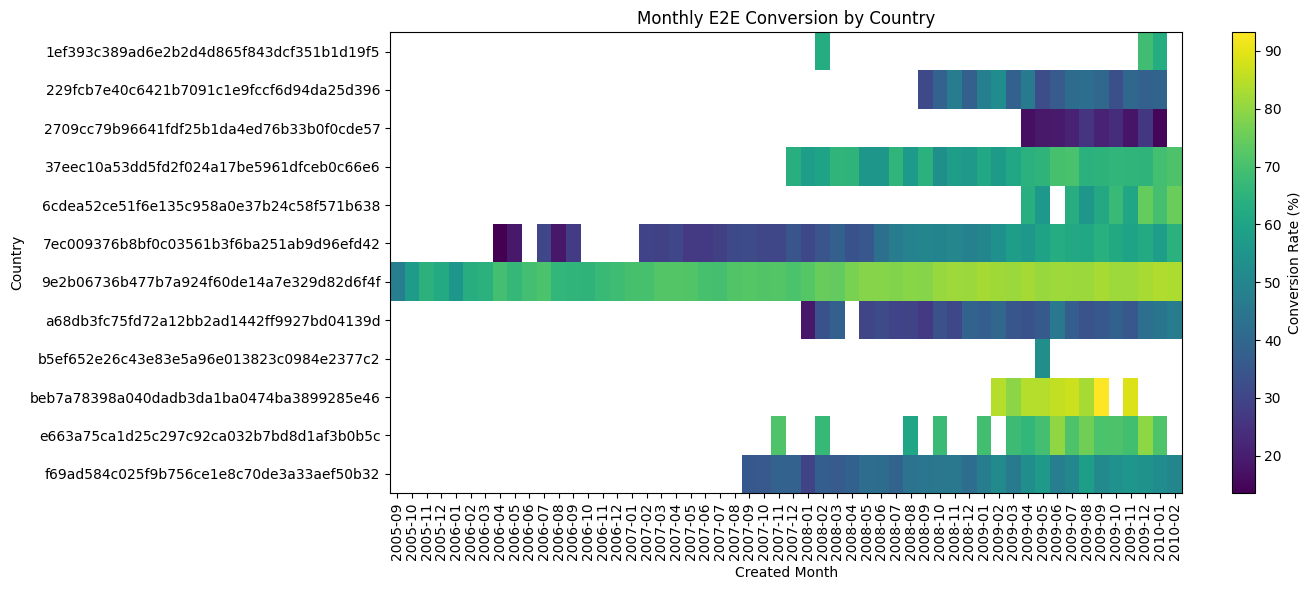

In [127]:
# Heatmap using matplotlib

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(
    country_pivot,
    aspect='auto'
)

ax.set_title('Monthly E2E Conversion by Country')
ax.set_xlabel('Created Month')
ax.set_ylabel('Country')

ax.set_yticks(range(len(country_pivot.index)))
ax.set_yticklabels(country_pivot.index)

x_labels = [str(x)[:7] for x in country_pivot.columns]
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Conversion Rate (%)')

plt.tight_layout()
plt.show()

In [128]:
# Identify sudden country-level conversion drops month over month

country_monthly_filtered = country_monthly_filtered.sort_values(
    ['country_id', 'created_month']
)

country_monthly_filtered['prev_conversion_pct'] = (
    country_monthly_filtered
    .groupby('country_id')['conversion_pct']
    .shift(1)
)

country_monthly_filtered['conversion_change_pp'] = (
    country_monthly_filtered['conversion_pct'] -
    country_monthly_filtered['prev_conversion_pct']
).round(2)

country_drops = (
    country_monthly_filtered[
        country_monthly_filtered['conversion_change_pp'] <= -10
    ]
    .sort_values('conversion_change_pp')
)

print(country_drops.head(15).to_string(index=False))

created_month                               country_id  payments  executed  conversion_pct  prev_conversion_pct  conversion_change_pp
   2009-03-01 229fcb7e40c6421b7091c1e9fccf6d94da25d396       104        40           38.46                52.38                -13.92
   2009-05-01 229fcb7e40c6421b7091c1e9fccf6d94da25d396       117        38           32.48                45.93                -13.45
   2006-08-01 7ec009376b8bf0c03561b3f6ba251ab9d96efd42       102        19           18.63                30.39                -11.76
   2010-01-01 2709cc79b96641fdf25b1da4ed76b33b0f0cde57       156        23           14.74                26.44                -11.70
   2008-10-01 37eec10a53dd5fd2f024a17be5961dfceb0c66e6       296       158           53.38                64.35                -10.97


In [129]:
# Cross-reference country drops with API version mix in the same month

if len(country_drops) > 0:
    drop_months = country_drops[['country_id', 'created_month']].drop_duplicates()

    drop_api_mix = df.merge(
        drop_months,
        on=['country_id', 'created_month'],
        how='inner'
    )

    drop_api_summary = (
        drop_api_mix
        .groupby(['country_id', 'created_month', 'api_version'])
        .agg(
            payments=('id', 'count'),
            executed=('is_executed', 'sum')
        )
        .reset_index()
    )

    drop_api_summary['conversion_pct'] = (
        drop_api_summary['executed'] / drop_api_summary['payments'] * 100
    ).round(2)

    print(drop_api_summary.sort_values(
        ['country_id', 'created_month', 'api_version']
    ).to_string(index=False))
else:
    print("No country-month conversion drops of 10 percentage points or more were found.")

                              country_id created_month api_version  payments  executed  conversion_pct
229fcb7e40c6421b7091c1e9fccf6d94da25d396    2009-03-01          v2       104        40           38.46
229fcb7e40c6421b7091c1e9fccf6d94da25d396    2009-05-01          v2       117        38           32.48
2709cc79b96641fdf25b1da4ed76b33b0f0cde57    2010-01-01          v3       156        23           14.74
37eec10a53dd5fd2f024a17be5961dfceb0c66e6    2008-10-01          v3       296       158           53.38
7ec009376b8bf0c03561b3f6ba251ab9d96efd42    2006-08-01          v1       102        19           18.63


#### Q2.4 Answer

The country-month heatmap shows that conversion is considerably different across countries. One country has payment activity across almost the full period and shows a clear improvement over time, reaching conversion rates over 80% by the end.

Several country-months show sudden conversion drops of more than 10 percentage points. The largest drops include country `229f...5396` in 2009-03 and 2009-05, both under API version `v2`, and country `2709...dc57` in 2010-01 under API version `v3`.

These drops do not appear to come from one single API version only. Instead, the drop table shows examples under `v1`, `v2`, and `v3`. This suggests that country-level conversion changes may be driven by local market, bank, or volume mix effects than only by API version.

In [130]:
# ============================================================
# Section 3 — Volume, TPV & AOV
# ============================================================

# 3.1  Overall payment volume metrics

executed_df = df[df['is_executed']].copy()
settled_df = df[df['is_settled']].copy()

tpv = executed_df['amount_in_currency'].sum()
executed_txn_count = len(executed_df)
settled_payment_count = len(settled_df)

aov = (
    settled_df['amount_in_currency'].sum() / settled_payment_count
    if settled_payment_count > 0 else np.nan
)

unique_users = executed_df['user_id'].nunique()
payments_per_user = executed_txn_count / unique_users

volume_summary = pd.DataFrame({
    'Metric': [
        'TPV',
        'Executed transaction count',
        'Settled payment count',
        'AOV',
        'Unique users',
        'Payments per user'
    ],
    'Value': [
        round(tpv, 2),
        executed_txn_count,
        settled_payment_count,
        round(aov, 2),
        unique_users,
        round(payments_per_user, 2)
    ]
})

print(volume_summary.to_string(index=False))

                    Metric         Value
                       TPV 10,341,631.20
Executed transaction count    377,616.00
     Settled payment count     73,360.00
                       AOV         13.55
              Unique users        153.00
         Payments per user      2,468.08


In [131]:
# 3.2  Summary table by vertical and connectivity type
# merchant_plan is not available in the combined CSV, so connectivity_type is used instead.

vertical_connectivity = (
    executed_df
    .groupby(['vertical', 'connectivity_type'], dropna=False)
    .agg(
        total_tpv=('amount_in_currency', 'sum'),
        transaction_count=('id', 'count')
    )
    .reset_index()
)

vertical_connectivity['aov'] = (
    vertical_connectivity['total_tpv'] / vertical_connectivity['transaction_count']
).round(2)

vertical_connectivity['pct_of_total_tpv'] = (
    vertical_connectivity['total_tpv'] / vertical_connectivity['total_tpv'].sum() * 100
).round(2)

vertical_connectivity = vertical_connectivity.sort_values(
    'total_tpv',
    ascending=False
)

print(vertical_connectivity.head(15).to_string(index=False))

  vertical connectivity_type    total_tpv  transaction_count    aov  pct_of_total_tpv
vertical 2            type 8 8,696,018.20             233899  37.18             84.09
vertical 4            type 8   438,890.72               9231  47.55              4.24
vertical 5            type 8   331,221.91             109067   3.04              3.20
vertical 2               NaN   282,542.74               5951  47.48              2.73
vertical 2            type 6   237,459.56               5325  44.59              2.30
vertical 2            type 2   111,098.91               1854  59.92              1.07
vertical 2            type 1    79,283.71               4565  17.37              0.77
vertical 2            type 7    53,798.56               3122  17.23              0.52
vertical 2            type 3    47,078.13                541  87.02              0.46
vertical 1            type 8    35,980.14                363  99.12              0.35
vertical 5            type 1    10,719.65             

In [132]:
# Top volume combination

top_combo = vertical_connectivity.head(1)

print(top_combo.to_string(index=False))

  vertical connectivity_type    total_tpv  transaction_count   aov  pct_of_total_tpv
vertical 2            type 8 8,696,018.20             233899 37.18             84.09


In [133]:
# 3.3  Monthly TPV and AOV

monthly_executed = (
    executed_df
    .groupby('created_month')
    .agg(
        tpv=('amount_in_currency', 'sum'),
        executed_transactions=('id', 'count')
    )
    .reset_index()
)

monthly_settled = (
    settled_df
    .groupby('created_month')
    .agg(
        settled_amount=('amount_in_currency', 'sum'),
        settled_payments=('id', 'count')
    )
    .reset_index()
)

monthly_volume = monthly_executed.merge(
    monthly_settled,
    on='created_month',
    how='left'
)

monthly_volume['aov'] = (
    monthly_volume['settled_amount'] / monthly_volume['settled_payments']
).round(2)

monthly_volume['tpv'] = monthly_volume['tpv'].round(2)

print(monthly_volume.head().to_string(index=False))
print(monthly_volume.tail().to_string(index=False))

created_month      tpv  executed_transactions  settled_amount  settled_payments  aov
   2005-05-01     3.00                      1             NaN               NaN  NaN
   2005-07-01   297.20                     35             NaN               NaN  NaN
   2005-08-01   481.02                     50             NaN               NaN  NaN
   2005-09-01 1,362.36                     96             NaN               NaN  NaN
   2005-10-01 2,531.57                    165             NaN               NaN  NaN
created_month        tpv  executed_transactions  settled_amount  settled_payments   aov
   2009-10-01 507,628.48                  21324       74,265.87          6,140.00 12.10
   2009-11-01 551,073.46                  23571       66,676.63          7,556.00  8.82
   2009-12-01 648,138.22                  26042       95,766.28          8,177.00 11.71
   2010-01-01 658,397.60                  27775      103,038.13          9,605.00 10.73
   2010-02-01 203,949.35                   9836   

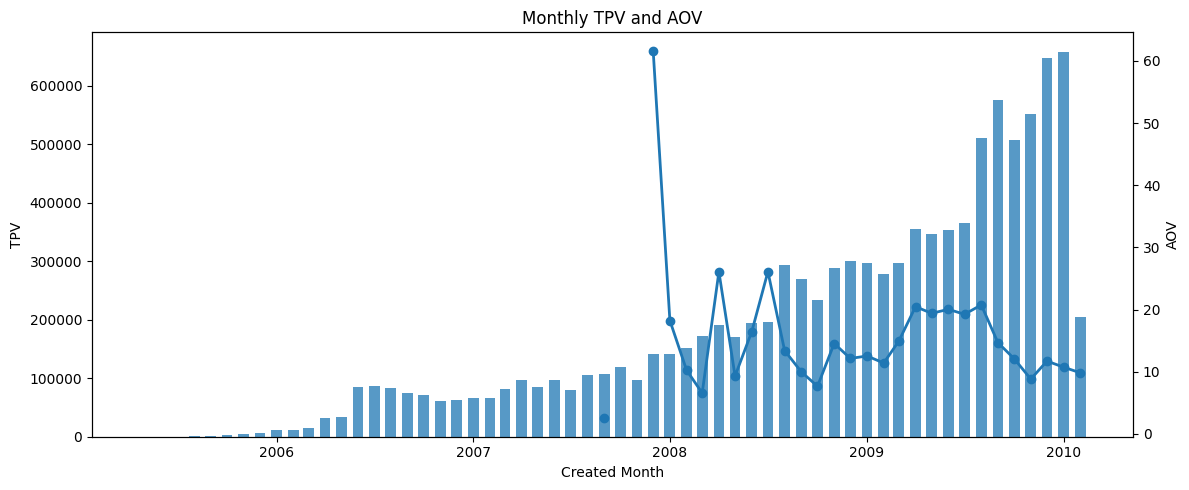

In [134]:
# Plot monthly TPV as bars and monthly AOV as line

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(
    monthly_volume['created_month'],
    monthly_volume['tpv'],
    width=20,
    alpha=0.75
)

ax1.set_title('Monthly TPV and AOV')
ax1.set_xlabel('Created Month')
ax1.set_ylabel('TPV')

ax2 = ax1.twinx()

ax2.plot(
    monthly_volume['created_month'],
    monthly_volume['aov'],
    marker='o',
    linewidth=2
)

ax2.set_ylabel('AOV')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Section 3 Answer

Total executed TPV is 10.34 million across 377,616 executed transactions. The dataset has 73,360 settled payments, and the settled-payment AOV is 13.55.

The volume is highly concentrated. Because `merchant_plan` isnt present in the csv, I used `vertical × connectivity_type` as the closest available breakdown. The largest combination is `vertical 2` with `type 8`, which contributes 8.70 million TPV, 233,899 transactions, and 84.09% of total TPV. This is clearly the main driver of volume.

Monthly TPV grows strongly over time, especially from 2008 and further. AOV does not move in the same direction as TPV. In the later period, TPV increases while AOV is mostly flat or declining, which could mean that growth is mainly coming from more transactions rather than larger average payment size.
The early monthly AOV values should be interpreted carefully because several early months have no settled payments, so AOV cannot be calculated for those months.

Q4.1 failure rate by reason and stage

In [135]:
# ============================================================
# Section 4 — Failure Analysis
# ============================================================

# 4.1  Overall failure rate

failed_df = df[df['is_failed']].copy()

total_payments = len(df)
failed_payments = len(failed_df)

failure_rate = failed_payments / total_payments * 100

print(f"Total payments: {total_payments:,}")
print(f"Failed payments: {failed_payments:,}")
print(f"Overall failure rate: {failure_rate:.2f}%")

Total payments: 500,000
Failed payments: 45,305
Overall failure rate: 9.06%


In [136]:
# Failure breakdown by reason

failure_reason_summary = (
    failed_df
    .groupby('failure_reason', dropna=False)
    .agg(
        failed_payments=('id', 'count')
    )
    .reset_index()
)

failure_reason_summary['failure_share_pct'] = (
    failure_reason_summary['failed_payments'] / failed_payments * 100
).round(2)

failure_reason_summary = failure_reason_summary.sort_values(
    'failed_payments',
    ascending=False
)

print(failure_reason_summary.to_string(index=False))

             failure_reason  failed_payments  failure_share_pct
                    expired            23173              51.15
             not_authorized             6561              14.48
          provider_rejected             5586              12.33
                   canceled             2797               6.17
  user_canceled_at_provider             2182               4.82
             provider_error             1307               2.88
         insufficient_funds             1098               2.42
           provider_expired             1047               2.31
                        NaN              684               1.51
      verification_declined              260               0.57
                   rejected              222               0.49
      internal_server_error              190               0.42
       constraint_violation               70               0.15
     payment_limit_exceeded               39               0.09
       authorization_failed             

In [137]:
# Failure breakdown by stage

failure_stage_summary = (
    failed_df
    .groupby('failure_stage', dropna=False)
    .agg(
        failed_payments=('id', 'count')
    )
    .reset_index()
)

failure_stage_summary['failure_share_pct'] = (
    failure_stage_summary['failed_payments'] / failed_payments * 100
).round(2)

failure_stage_summary = failure_stage_summary.sort_values(
    'failed_payments',
    ascending=False
)

print(failure_stage_summary.to_string(index=False))

         failure_stage  failed_payments  failure_share_pct
             initiated            23311              51.45
           authorizing            13093              28.90
            authorized             6147              13.57
authorization_required             1810               4.00
                   NaN              684               1.51
             suspended              260               0.57


In [138]:
# Failure reason by failure stage

failure_reason_stage = (
    failed_df
    .groupby(['failure_reason', 'failure_stage'], dropna=False)
    .agg(
        failed_payments=('id', 'count')
    )
    .reset_index()
)

failure_reason_stage['failure_share_pct'] = (
    failure_reason_stage['failed_payments'] / failed_payments * 100
).round(2)

failure_reason_stage = failure_reason_stage.sort_values(
    'failed_payments',
    ascending=False
)

print(failure_reason_stage.head(20).to_string(index=False))

           failure_reason          failure_stage  failed_payments  failure_share_pct
                  expired              initiated            13240              29.22
                  expired            authorizing             8609              19.00
        provider_rejected             authorized             5392              11.90
           not_authorized              initiated             4169               9.20
           not_authorized            authorizing             2392               5.28
user_canceled_at_provider              initiated             1996               4.41
                 canceled              initiated             1819               4.02
                  expired authorization_required             1324               2.92
                 canceled            authorizing              968               2.14
         provider_expired              initiated              936               2.07
                      NaN                    NaN              684

#### Q4.1 Answer

The overall failure rate is 9.06%, with 45,305 failed payments out of 500,000 total payments.

The most common failure reason is `expired`, which accounts for 23,173 failed payments, or 51.15% of all failures. The next largest reasons are `not_authorized` and `provider_rejected`, but both are much smaller than `expired`.

Failures are concentrated mainly at the `initiated` stage, which accounts for 51.45% of failed payments. The largest reason-stage combination is `expired` at the `initiated` stage, with 13,240 failures. This means that many failures happen early in the payment journey before the user or provider completes the next step.

In [139]:
# 4.2  Bank failure / cancellation / success rates

bank_summary = df.groupby('bank_id').agg(
    total=('id', 'count'),
    failed=('is_failed', 'sum'),
    cancelled=('is_cancelled', 'sum'),
    executed=('is_executed', 'sum')
)

bank_summary = bank_summary[bank_summary['total'] >= 30].copy()

bank_summary['failure_rate'] = (bank_summary['failed'] / bank_summary['total'] * 100).round(2)
bank_summary['cancellation_rate'] = (bank_summary['cancelled'] / bank_summary['total'] * 100).round(2)
bank_summary['success_rate'] = (bank_summary['executed'] / bank_summary['total'] * 100).round(2)

bank_summary['bank_short'] = bank_summary.index.str[:14] + '...'

failure_threshold = bank_summary['failure_rate'].mean() + 2 * bank_summary['failure_rate'].std()
cancel_threshold = bank_summary['cancellation_rate'].mean() + 2 * bank_summary['cancellation_rate'].std()

bank_summary['outlier'] = (
    (bank_summary['failure_rate'] > failure_threshold) |
    (bank_summary['cancellation_rate'] > cancel_threshold)
)

print('Top 10 Banks by Failure Rate (min 30 payments):')
print(
    bank_summary
    .sort_values('failure_rate', ascending=False)
    .head(10)[['bank_short','total','failed','cancelled','executed',
               'failure_rate','cancellation_rate','success_rate','outlier']]
    .to_string()
)

print()
print(f'Failure outlier threshold     : {failure_threshold:.2f}%')
print(f'Cancellation outlier threshold: {cancel_threshold:.2f}%')
print(f'Outlier banks                 : {bank_summary["outlier"].sum()}')

Top 10 Banks by Failure Rate (min 30 payments):
                                                 bank_short  total  failed  cancelled  executed  failure_rate  cancellation_rate  success_rate  outlier
bank_id                                                                                                                                                
6e98f6d55096ecb8a0ff2f7fadbc69dd58d34c00  6e98f6d55096ec...    305     264          0         0         86.56               0.00          0.00     True
60225953c522a8c3382a702b8114f5b7b30d021e  60225953c522a8...    247     119          0       117         48.18               0.00         47.37     True
4d9376776e819ea20c4ed1e0ff7fcb07ff3abdb5  4d9376776e819e...    177      81          0        71         45.76               0.00         40.11     True
83ea4c6fc55750d2bfec35f495048cfdcc9260d6  83ea4c6fc55750...     56      22          0        20         39.29               0.00         35.71     True
c0f269ba81fb387123508598172f5302f8cc95f2

In [140]:
# Outlier bank table

outlier_banks = (
    bank_summary[bank_summary['outlier']]
    .sort_values(['failure_rate', 'cancellation_rate'], ascending=False)
)

print('Outlier Banks:')
print(
    outlier_banks[['bank_short','total','failed','cancelled','executed',
                   'failure_rate','cancellation_rate','success_rate']]
    .to_string()
)

Outlier Banks:
                                                 bank_short  total  failed  cancelled  executed  failure_rate  cancellation_rate  success_rate
bank_id                                                                                                                                       
6e98f6d55096ecb8a0ff2f7fadbc69dd58d34c00  6e98f6d55096ec...    305     264          0         0         86.56               0.00          0.00
60225953c522a8c3382a702b8114f5b7b30d021e  60225953c522a8...    247     119          0       117         48.18               0.00         47.37
4d9376776e819ea20c4ed1e0ff7fcb07ff3abdb5  4d9376776e819e...    177      81          0        71         45.76               0.00         40.11
83ea4c6fc55750d2bfec35f495048cfdcc9260d6  83ea4c6fc55750...     56      22          0        20         39.29               0.00         35.71
c0f269ba81fb387123508598172f5302f8cc95f2  c0f269ba81fb38...     55      21          0        31         38.18               0.0

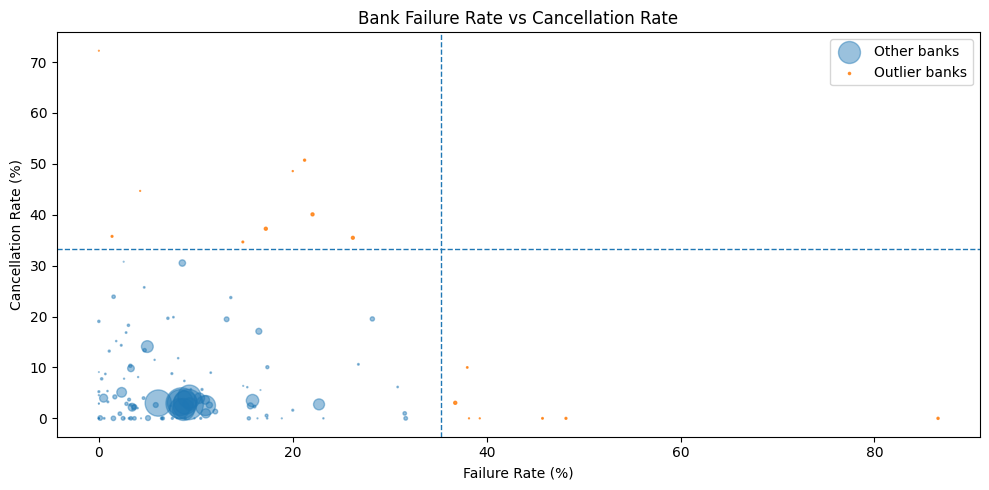

In [141]:
# bank_type is not available, so outliers are highlighted instead.

fig, ax = plt.subplots(figsize=(10, 5))

normal = bank_summary[~bank_summary['outlier']]
outliers = bank_summary[bank_summary['outlier']]

ax.scatter(
    normal['failure_rate'],
    normal['cancellation_rate'],
    s=(normal['total'] / bank_summary['total'].max()) * 500,
    alpha=0.45,
    label='Other banks'
)

ax.scatter(
    outliers['failure_rate'],
    outliers['cancellation_rate'],
    s=(outliers['total'] / bank_summary['total'].max()) * 500,
    alpha=0.8,
    label='Outlier banks'
)

ax.axvline(failure_threshold, linestyle='--', linewidth=1)
ax.axhline(cancel_threshold, linestyle='--', linewidth=1)

ax.set_title('Bank Failure Rate vs Cancellation Rate')
ax.set_xlabel('Failure Rate (%)')
ax.set_ylabel('Cancellation Rate (%)')
ax.legend()

plt.tight_layout()
plt.show()

The bank-level analysis keeps only banks with at least 30 payments. For each bank, I calculated failure rate, cancellation rate, and success rate.

The failure outlier threshold is 35.31%, and the cancellation outlier threshold is 33.34%. In total, 16 banks are flagged as outliers. Some banks are failure-rate outliers, while others are cancellation-rate outliers.

The highest failure-rate bank has 305 payments, 264 failures, and a failure rate of 86.56%. Several other banks also have failure rates above the threshold, including banks with failure rates of 48.18%, 45.76%, and 39.29%.

The original instruction asks for the scatter plot to be coloured by `bank_type`, but this field is not available in the combined CSV. Because of that, the plot highlights outlier banks instead. Most banks are clustered near low failure and low cancellation rates, while a smaller group of banks sits far away from the main cluster and should be investigated further.

In [142]:
# 4.3  Focus on expired failures

expired_df = failed_df[failed_df['failure_reason'] == 'expired'].copy()

expired_failures = len(expired_df)
expired_share = expired_failures / failed_payments * 100

print(f"Expired failures: {expired_failures:,}")
print(f"Share of all failures: {expired_share:.2f}%")

Expired failures: 23,173
Share of all failures: 51.15%


In [143]:
# Expired failure rate by API version

expired_api = (
    df.groupby('api_version')
      .agg(
          payments=('id', 'count'),
          failures=('is_failed', 'sum'),
          expired_failures=('failure_reason', lambda x: (x == 'expired').sum())
      )
      .reset_index()
)

expired_api['failure_rate'] = (
    expired_api['failures'] / expired_api['payments'] * 100
).round(2)

expired_api['expired_rate_all_payments'] = (
    expired_api['expired_failures'] / expired_api['payments'] * 100
).round(2)

expired_api['expired_share_of_failures'] = (
    expired_api['expired_failures'] / expired_api['failures'] * 100
).round(2)

print(expired_api.to_string(index=False))

api_version  payments  failures  expired_failures  failure_rate  expired_rate_all_payments  expired_share_of_failures
         v1     96212       478                 0          0.50                       0.00                       0.00
         v2    162651       206                 0          0.13                       0.00                       0.00
         v3    241137     44621             23173         18.50                       9.61                      51.93


In [144]:
# Expired failure concentration by bank
# bank_type is not available, so bank_id is used as the closest available bank-level cut.

expired_bank = (
    df.groupby('bank_id')
      .agg(
          payments=('id', 'count'),
          failures=('is_failed', 'sum'),
          expired_failures=('failure_reason', lambda x: (x == 'expired').sum())
      )
)

expired_bank = expired_bank[expired_bank['payments'] >= 30].copy()

expired_bank['failure_rate'] = (
    expired_bank['failures'] / expired_bank['payments'] * 100
).round(2)

expired_bank['expired_rate_all_payments'] = (
    expired_bank['expired_failures'] / expired_bank['payments'] * 100
).round(2)

expired_bank['expired_share_of_failures'] = (
    expired_bank['expired_failures'] / expired_bank['failures'] * 100
).round(2)

expired_bank['bank_short'] = expired_bank.index.str[:14] + '...'

print(
    expired_bank
    .sort_values('expired_rate_all_payments', ascending=False)
    .head(15)[['bank_short','payments','failures','expired_failures',
               'failure_rate','expired_rate_all_payments','expired_share_of_failures']]
    .to_string()
)

                                                 bank_short  payments  failures  expired_failures  failure_rate  expired_rate_all_payments  expired_share_of_failures
bank_id                                                                                                                                                              
6e98f6d55096ecb8a0ff2f7fadbc69dd58d34c00  6e98f6d55096ec...       305       264               220         86.56                      72.13                      83.33
07ff6bf02b22c36bc8089c4ae27fe57918679e80  07ff6bf02b22c3...       146        45                37         30.82                      25.34                      82.22
2ef35913f1ed772d2fda14f097bc4d9b7b5026cc  2ef35913f1ed77...       198        53                43         26.77                      21.72                      81.13
60225953c522a8c3382a702b8114f5b7b30d021e  60225953c522a8...       247       119                47         48.18                      19.03                      39.50
4d93

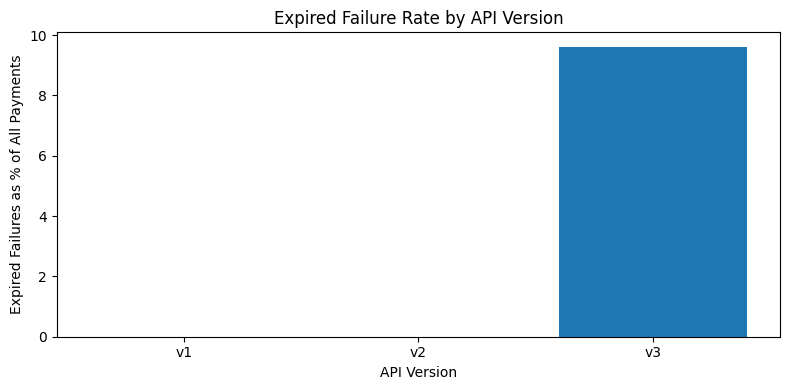

In [145]:
# Plot expired failure rate by API version

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    expired_api['api_version'],
    expired_api['expired_rate_all_payments']
)

ax.set_title('Expired Failure Rate by API Version')
ax.set_xlabel('API Version')
ax.set_ylabel('Expired Failures as % of All Payments')

plt.tight_layout()
plt.show()

`expired` is the dominant failure reason. There are 23,173 expired failures, which represents 51.15% of all failed payments.

The expired failure pattern differs strongly by API version. `v1` and `v2` have zero recorded expired failures, while `v3` has all 23,173 expired failures. For `v3`, expired failures make up 9.61% of all payments and 51.93% of failed payments.

This does not necessarily mean that expiry only existed in `v3`. Earlier data quality checks showed that failed payments in `v1` and `v2` have missing `failure_reason`, so the difference is likely partly caused by better failure reason tracking in `v3`.

The instruction also asks for comparison by `bank_type`, but `bank_type` is not available in the combined CSV. As a substitute, I checked expiry concentration by `bank_id`. Some banks have very high expired failure rates, including one bank where 72.13% of all payments are expired failures. These banks should be investigated because they may have timeout, user journey, or provider-side completion issues.

In [146]:
# ============================================================
# Section 5 — Latency Analysis
# ============================================================

# 5.1  Latency between consecutive payment stages

latency_df = executed_df.copy()

latency_df['created_to_initiated_sec'] = (
    latency_df['initiated_at'] - latency_df['createdat_ts']
).dt.total_seconds()

latency_df['initiated_to_authorizing_sec'] = (
    latency_df['authorizing_at'] - latency_df['initiated_at']
).dt.total_seconds()

latency_df['authorizing_to_authorized_sec'] = (
    latency_df['authorized_at'] - latency_df['authorizing_at']
).dt.total_seconds()

latency_df['authorized_to_executed_sec'] = (
    latency_df['executed_at'] - latency_df['authorized_at']
).dt.total_seconds()

latency_df['created_to_executed_sec'] = (
    latency_df['executed_at'] - latency_df['createdat_ts']
).dt.total_seconds()

latency_cols = [
    'created_to_initiated_sec',
    'initiated_to_authorizing_sec',
    'authorizing_to_authorized_sec',
    'authorized_to_executed_sec',
    'created_to_executed_sec'
]

latency_summary = []

for col in latency_cols:
    x = latency_df[col].dropna()
    x = x[x >= 0]
    
    latency_summary.append({
        'latency_metric': col,
        'rows': len(x),
        'mean': round(x.mean(), 2),
        'median': round(x.median(), 2),
        'p95': round(x.quantile(0.95), 2),
        'p99': round(x.quantile(0.99), 2)
    })

latency_summary = pd.DataFrame(latency_summary)

print(latency_summary.to_string(index=False))

               latency_metric   rows     mean  median    p95    p99
     created_to_initiated_sec 191555     4.82    3.62  13.38  28.75
 initiated_to_authorizing_sec  78116     0.00    0.00   0.00   0.00
authorizing_to_authorized_sec 191555    41.00   28.86  85.90 211.72
   authorized_to_executed_sec 191412   209.52    2.41   6.54  29.16
      created_to_executed_sec 377610 1,347.18   34.69 112.14 813.76


In [147]:
# 5.2  E2E latency histogram capped at 600 seconds

e2e_latency = latency_df['created_to_executed_sec'].dropna()
e2e_latency = e2e_latency[e2e_latency >= 0]

e2e_latency_capped = e2e_latency[e2e_latency <= 600]

median_latency = e2e_latency.median()
p95_latency = e2e_latency.quantile(0.95)

print(f"Median E2E latency: {median_latency:.2f} seconds")
print(f"P95 E2E latency   : {p95_latency:.2f} seconds")
print(f"Rows in histogram : {len(e2e_latency_capped):,}")

Median E2E latency: 34.69 seconds
P95 E2E latency   : 112.14 seconds
Rows in histogram : 372,899


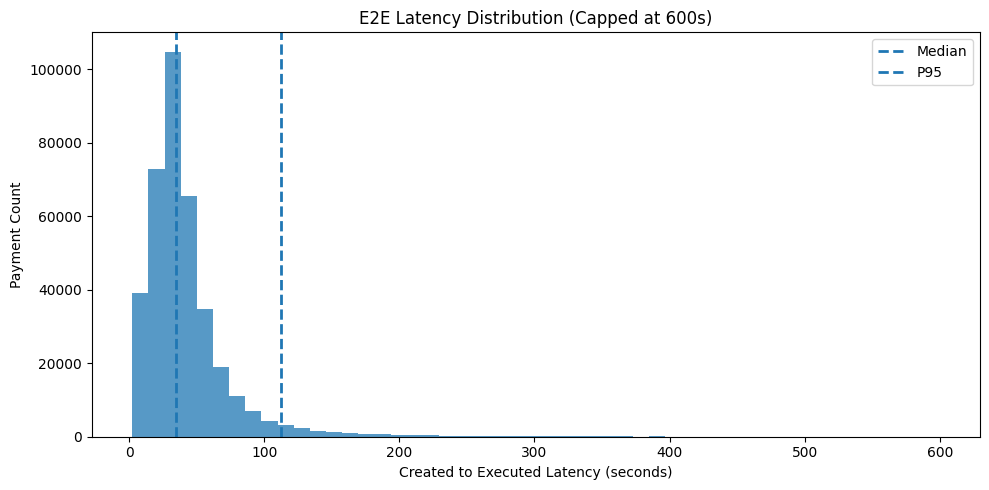

In [148]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    e2e_latency_capped,
    bins=50,
    alpha=0.75
)

ax.axvline(median_latency, linestyle='--', linewidth=2, label='Median')
ax.axvline(p95_latency, linestyle='--', linewidth=2, label='P95')

ax.set_title('E2E Latency Distribution (Capped at 600s)')
ax.set_xlabel('Created to Executed Latency (seconds)')
ax.set_ylabel('Payment Count')
ax.legend()

plt.tight_layout()
plt.show()

#### Q5.1–Q5.2 Answer

For executed payments, the median end-to-end latency from creation to execution is 34.69 seconds, while the p95 is 112.14 seconds. This means most payments complete within roughly one to two minutes.

The distribution is clearly right-skewed. Most payments are concentrated at low latency values, but a smaller number of payments take much longer. This is also visible from the gap between the mean and the median where mean E2E latency is higher than the median because of long-tail cases.

A long tail in payment latency can hurt user experience because users may abandon the flow, retry the payment, or assume the payment failed even if it eventually completes.

In [149]:
# 5.3  E2E latency by connectivity type and bank

latency_df['e2e_latency_sec'] = latency_df['created_to_executed_sec']

latency_valid = latency_df[
    latency_df['e2e_latency_sec'].notna() &
    (latency_df['e2e_latency_sec'] >= 0)
].copy()

connectivity_latency = (
    latency_valid
    .groupby('connectivity_type', dropna=False)
    .agg(
        payments=('id', 'count'),
        median_latency=('e2e_latency_sec', 'median'),
        p95_latency=('e2e_latency_sec', lambda x: x.quantile(0.95))
    )
    .reset_index()
)

connectivity_latency['median_latency'] = connectivity_latency['median_latency'].round(2)
connectivity_latency['p95_latency'] = connectivity_latency['p95_latency'].round(2)

connectivity_latency = connectivity_latency.sort_values('p95_latency', ascending=False)

print(connectivity_latency.to_string(index=False))

connectivity_type  payments  median_latency  p95_latency
           type 2      2579           69.83    82,263.75
              NaN      5949           72.63    79,845.64
           type 6      5326           64.79    14,939.58
           type 7      3123           71.59       813.86
           type 1      5986           48.14       813.19
           type 3      1780           39.03       100.84
           type 8    352867           33.72        97.91


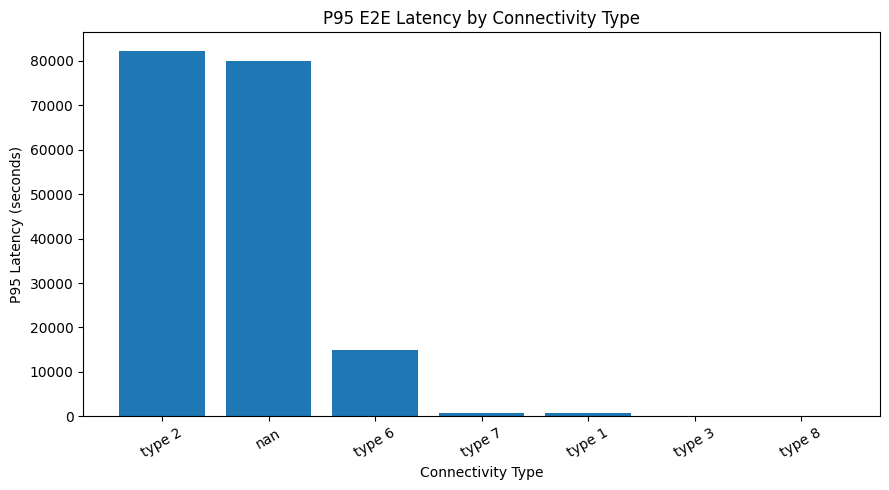

In [150]:
# Bar chart by connectivity type

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    connectivity_latency['connectivity_type'].astype(str),
    connectivity_latency['p95_latency']
)

ax.set_title('P95 E2E Latency by Connectivity Type')
ax.set_xlabel('Connectivity Type')
ax.set_ylabel('P95 Latency (seconds)')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [151]:
# Bank-level latency table sorted by p95
# Keep banks with enough executed payments to make p95 meaningful.

bank_latency = (
    latency_valid
    .groupby('bank_id')
    .agg(
        payments=('id', 'count'),
        median_latency=('e2e_latency_sec', 'median'),
        p95_latency=('e2e_latency_sec', lambda x: x.quantile(0.95))
    )
)

bank_latency = bank_latency[bank_latency['payments'] >= 30].copy()

bank_latency['median_latency'] = bank_latency['median_latency'].round(2)
bank_latency['p95_latency'] = bank_latency['p95_latency'].round(2)
bank_latency['bank_short'] = bank_latency.index.str[:14] + '...'

bank_latency = bank_latency.sort_values('p95_latency', ascending=False)

print(
    bank_latency
    .head(15)[['bank_short','payments','median_latency','p95_latency']]
    .to_string()
)

                                                 bank_short  payments  median_latency  p95_latency
bank_id                                                                                           
6c135101d303aa38bbe56a9b0d9e95db2247d588  6c135101d303aa...        69       87,112.18   316,944.89
603364a15bf8abd4b8a2f7d46e6934c397ced244  603364a15bf8ab...       162       69,195.72   255,314.48
c3fe3fe441baa5eb1e9cc1214320d5a65fecb397  c3fe3fe441baa5...       281       40,308.50   231,606.71
d497dd6c1ee4bdbf6a6bbe2520b8100c04a20b07  d497dd6c1ee4bd...       231       36,803.48   215,285.61
7f88f8bd29d554cfd6794d5f4b2e589422fd0728  7f88f8bd29d554...       356           76.49   214,313.23
8b408eb9070e2b1dbb590cd7ffe0f467b490a66a  8b408eb9070e2b...       200       80,102.99   206,421.43
51e5c4e192ab09a16eae9c7ade1c98cefe32427f  51e5c4e192ab09...        57           58.41   198,186.39
a8a270ee31995a10a17bd0f10e17c238937f24e9  a8a270ee31995a...       134          151.62   172,819.97
5f832a6dbf

In [152]:
# Check whether high latency is correlated with high failure rate

bank_latency_failure = bank_latency.merge(
    bank_summary[['failure_rate', 'cancellation_rate', 'success_rate']],
    left_index=True,
    right_index=True,
    how='left'
)

latency_failure_corr = bank_latency_failure[['p95_latency', 'failure_rate']].corr().iloc[0, 1]

print(f"Correlation between bank p95 latency and failure rate: {latency_failure_corr:.3f}")

print(
    bank_latency_failure
    .head(15)[['bank_short','payments','median_latency','p95_latency',
               'failure_rate','cancellation_rate','success_rate']]
    .to_string()
)

Correlation between bank p95 latency and failure rate: 0.017
                                                 bank_short  payments  median_latency  p95_latency  failure_rate  cancellation_rate  success_rate
bank_id                                                                                                                                          
6c135101d303aa38bbe56a9b0d9e95db2247d588  6c135101d303aa...        69       87,112.18   316,944.89         21.22              50.72         24.82
603364a15bf8abd4b8a2f7d46e6934c397ced244  603364a15bf8ab...       162       69,195.72   255,314.48         13.61              23.73         51.27
c3fe3fe441baa5eb1e9cc1214320d5a65fecb397  c3fe3fe441baa5...       281       40,308.50   231,606.71          6.60               0.00         41.20
d497dd6c1ee4bdbf6a6bbe2520b8100c04a20b07  d497dd6c1ee4bd...       231       36,803.48   215,285.61          1.52              23.89         29.33
7f88f8bd29d554cfd6794d5f4b2e589422fd0728  7f88f8bd29d554...    

#### Q5.3 Answer

Latency differs strongly by connectivity type. `type 2` and missing connectivity values have the highest p95 latency, while `type 8` has a much lower p95 latency. which means that most volume may be processed through a relatively faster connectivity type, while some of the smaller connectivity groups have long-tail latency.

At the bank level, the worst p95 latency values are extremely high. This means that some banks have a small but important group of very slow payments, even if their median latency is not always high.

The correlation between bank p95 latency and failure rate is 0.017, which is very close to zero. Based on this, high latency does not appear to be strongly related to high failure rate at the bank system


In [153]:
# ============================================================
# Section 6 — User Classification
# ============================================================

# 6.1  Add user_stage column

df = df.sort_values(['user_id', 'createdat_ts']).copy()

df['attempt_number'] = df.groupby('user_id').cumcount() + 1

first_success = (
    df[df['is_executed']]
    .groupby('user_id')['createdat_ts']
    .min()
)

df['first_success_at'] = df['user_id'].map(first_success)

df['user_stage'] = 'New User'

df.loc[df['attempt_number'] == 1, 'user_stage'] = 'First Attempt'

df.loc[
    df['first_success_at'].notna() &
    (df['createdat_ts'] > df['first_success_at']),
    'user_stage'
] = 'Returning User'

print(df[['user_id','createdat_ts','status_clean','attempt_number',
          'first_success_at','user_stage']].head(20).to_string(index=False))

                                 user_id               createdat_ts status_clean  attempt_number           first_success_at     user_stage
00ae9f8045bcf12a3d5781669534b7c1700e853f 2009-03-20 13:49:43.588248     executed               1 2009-03-20 13:49:43.588248  First Attempt
00f1128736a069a97d96aeff5154595a9824e81d 2007-11-08 10:41:09.944711    cancelled               1 2008-02-12 15:41:36.787414  First Attempt
00f1128736a069a97d96aeff5154595a9824e81d 2007-12-29 13:42:38.297908    initiated               2 2008-02-12 15:41:36.787414       New User
00f1128736a069a97d96aeff5154595a9824e81d 2008-01-16 12:42:58.014523    initiated               3 2008-02-12 15:41:36.787414       New User
00f1128736a069a97d96aeff5154595a9824e81d 2008-01-23 11:44:41.422973    initiated               4 2008-02-12 15:41:36.787414       New User
00f1128736a069a97d96aeff5154595a9824e81d 2008-02-12 15:41:36.787414     executed               5 2008-02-12 15:41:36.787414       New User
00f1128736a069a97d96aeff515

In [154]:
# Check user_stage distribution

user_stage_counts = (
    df['user_stage']
    .value_counts()
    .reset_index()
)

user_stage_counts.columns = ['user_stage', 'payments']

print(user_stage_counts.to_string(index=False))

    user_stage  payments
Returning User    499489
      New User       338
 First Attempt       173


In [155]:
# 6.2  Payment count, conversion rate, and average amount by user_stage

user_stage_summary = (
    df.groupby('user_stage')
      .agg(
          payments=('id', 'count'),
          executed=('is_executed', 'sum'),
          avg_amount=('amount_in_currency', 'mean')
      )
      .reset_index()
)

user_stage_summary['conversion_rate'] = (
    user_stage_summary['executed'] / user_stage_summary['payments'] * 100
).round(2)

user_stage_summary['avg_amount'] = user_stage_summary['avg_amount'].round(2)

user_stage_summary = user_stage_summary[
    ['user_stage', 'payments', 'executed', 'conversion_rate', 'avg_amount']
]

print(user_stage_summary.to_string(index=False))

    user_stage  payments  executed  conversion_rate  avg_amount
 First Attempt       173        68            39.31      116.75
      New User       338        85            25.15      447.50
Returning User    499489    377463            75.57       57.77


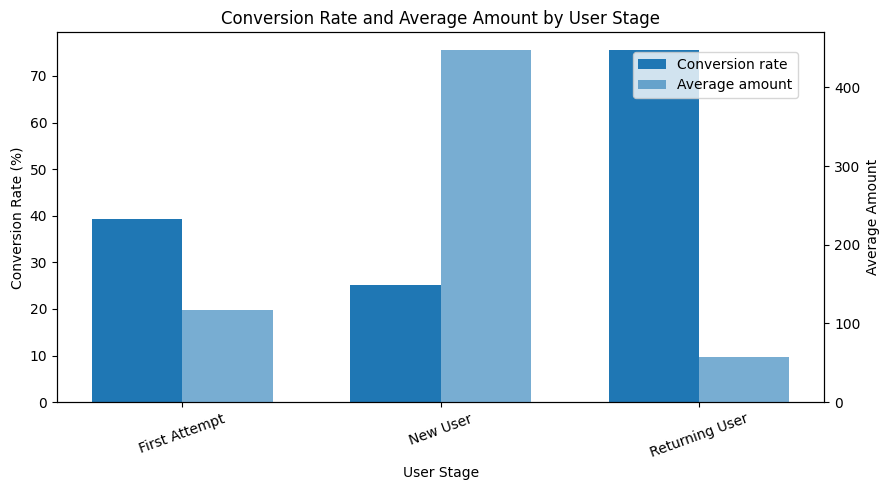

In [156]:
# Grouped bar chart for conversion rate and average amount

x = np.arange(len(user_stage_summary))
width = 0.35

fig, ax1 = plt.subplots(figsize=(9, 5))

bars1 = ax1.bar(
    x - width / 2,
    user_stage_summary['conversion_rate'],
    width,
    label='Conversion rate'
)

ax1.set_ylabel('Conversion Rate (%)')
ax1.set_xlabel('User Stage')
ax1.set_title('Conversion Rate and Average Amount by User Stage')
ax1.set_xticks(x)
ax1.set_xticklabels(user_stage_summary['user_stage'], rotation=20)

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width / 2,
    user_stage_summary['avg_amount'],
    width,
    alpha=0.6,
    label='Average amount'
)

ax2.set_ylabel('Average Amount')

fig.legend(
    loc='upper right',
    bbox_to_anchor=(0.9, 0.9)
)

plt.tight_layout()
plt.show()

#### Q6.1–Q6.2 Answer

Users were classified using the homework definitions: first attempt is the first payment attempt ever, new user attempts are attempts up to and including the first successful payment, and returning user attempts are attempts after the first success.

Most payments are from returning users. There are 499,489 returning-user attempts, compared with only 173 first attempts and 338 new-user attempts. This shows that payment activity is heavily concentrated among users who have already succeeded at least once.

Returning users have the highest conversion rate at 75.57%. First attempts convert at 39.31%, while new-user attempts convert at 25.15%. Returning users likely convert better because they have already completed the payment journey before, may be using familiar banks or flows, and are less likely to abandon during setup or authorization.

In [157]:
# 6.3  Days from first attempt to first successful payment

first_attempt = (
    df.groupby('user_id')['createdat_ts']
      .min()
)

first_success = (
    df[df['is_executed']]
    .groupby('user_id')['createdat_ts']
    .min()
)

user_conversion_time = pd.DataFrame({
    'first_attempt_at': first_attempt,
    'first_success_at': first_success
})

user_conversion_time['days_to_first_success'] = (
    user_conversion_time['first_success_at'] - user_conversion_time['first_attempt_at']
).dt.total_seconds() / (60 * 60 * 24)

user_conversion_time = user_conversion_time[
    user_conversion_time['days_to_first_success'].notna() &
    (user_conversion_time['days_to_first_success'] >= 0)
].copy()

median_days = user_conversion_time['days_to_first_success'].median()
converted_7d_pct = (
    (user_conversion_time['days_to_first_success'] <= 7).mean() * 100
)

print(f"Users with first success: {len(user_conversion_time):,}")
print(f"Median days to first success: {median_days:.2f}")
print(f"% converting within 7 days: {converted_7d_pct:.2f}%")

print(user_conversion_time.head(10).to_string())

Users with first success: 153
Median days to first success: 1.09
% converting within 7 days: 62.75%
                                                   first_attempt_at           first_success_at  days_to_first_success
user_id                                                                                                              
00ae9f8045bcf12a3d5781669534b7c1700e853f 2009-03-20 13:49:43.588248 2009-03-20 13:49:43.588248                   0.00
00f1128736a069a97d96aeff5154595a9824e81d 2007-11-08 10:41:09.944711 2008-02-12 15:41:36.787414                  96.21
01e10adf72398bdf40b668926be2809ccf68b4dd 2006-08-22 14:24:05.657120 2006-08-22 14:24:05.657120                   0.00
02abfe216906d699a48d39d56b71327b294027cb 2008-05-29 17:24:27.211572 2008-05-29 17:24:27.211572                   0.00
030e085f49a63c537c4461eb5fc036d4086c2cc0 2007-02-08 15:00:41.016008 2007-02-08 15:00:41.016008                   0.00
03bdc906cb6d5941a654ae715b7ceba07a1f9545 2005-07-09 23:02:50.635085 2005-0

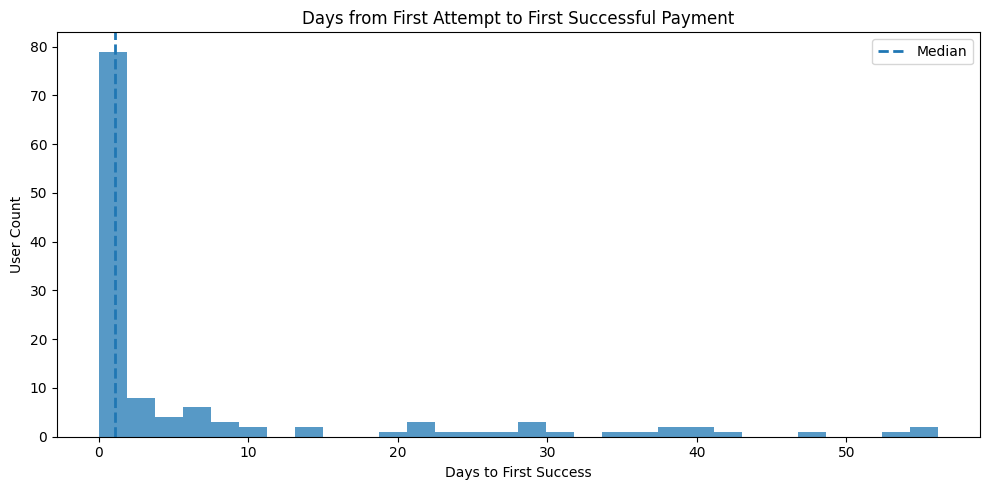

In [158]:
# Plot distribution capped at 60 days

days_capped = user_conversion_time[
    user_conversion_time['days_to_first_success'] <= 60
]['days_to_first_success']

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    days_capped,
    bins=30,
    alpha=0.75
)

ax.axvline(median_days, linestyle='--', linewidth=2, label='Median')

ax.set_title('Days from First Attempt to First Successful Payment')
ax.set_xlabel('Days to First Success')
ax.set_ylabel('User Count')
ax.legend()

plt.tight_layout()
plt.show()

#### Q6.3 Answer

Out of 173 users, 153 eventually make a first successful payment. The median time from first attempt to first success is 1.09 days, which means that users who convert usually do so quickly.

62.75% of users with a first success convert within 7 days. The distribution is right-skewed: most successful users convert early, but a smaller group takes several weeks before their first successful payment.

This suggests that the first few days after a user’s first attempt are especially important for activation. Users who do not succeed quickly may need better retry flows, clearer error messages, or follow-up support.

In [159]:
# ============================================================
# Section 7 — Frequency Tiers & RFM Analysis
# ============================================================

# 7.1  Frequency tiers using executed payments only

user_freq = (
    executed_df
    .groupby('user_id')
    .agg(
        executed_payments=('id', 'count'),
        total_tpv=('amount_in_currency', 'sum')
    )
)

def assign_frequency_tier(x):
    if x >= 15:
        return 'Champion'
    elif x >= 8:
        return 'Super'
    elif x >= 4:
        return 'Engaged'
    elif x >= 2:
        return 'Light'
    else:
        return 'Inactive'

user_freq['frequency_tier'] = user_freq['executed_payments'].apply(assign_frequency_tier)

tier_summary = (
    user_freq
    .groupby('frequency_tier')
    .agg(
        users=('executed_payments', 'count'),
        total_tpv=('total_tpv', 'sum'),
        avg_executed_payments=('executed_payments', 'mean')
    )
    .reset_index()
)

tier_summary['user_pct'] = (
    tier_summary['users'] / tier_summary['users'].sum() * 100
).round(2)

tier_summary['tpv_pct'] = (
    tier_summary['total_tpv'] / tier_summary['total_tpv'].sum() * 100
).round(2)

tier_summary['avg_executed_payments'] = tier_summary['avg_executed_payments'].round(2)
tier_summary['total_tpv'] = tier_summary['total_tpv'].round(2)

tier_order = ['Champion', 'Super', 'Engaged', 'Light', 'Inactive']
tier_summary['tier_order'] = tier_summary['frequency_tier'].map({
    'Champion': 1,
    'Super': 2,
    'Engaged': 3,
    'Light': 4,
    'Inactive': 5
})

tier_summary = tier_summary.sort_values('tier_order').drop(columns='tier_order')

print(tier_summary.to_string(index=False))

frequency_tier  users     total_tpv  avg_executed_payments  user_pct  tpv_pct
      Champion     95 10,329,762.32               3,972.40     62.09    99.89
         Super     12      6,957.99                  11.08      7.84     0.07
       Engaged     10      1,494.28                   5.10      6.54     0.01
         Light     11      2,423.92                   2.64      7.19     0.02
      Inactive     25        992.69                   1.00     16.34     0.01


In [160]:
# Pareto table: cumulative users vs cumulative TPV

pareto = user_freq.sort_values('total_tpv', ascending=False).copy()

pareto['user_rank'] = np.arange(1, len(pareto) + 1)

pareto['cum_users_pct'] = (
    pareto['user_rank'] / len(pareto) * 100
).round(2)

pareto['cum_tpv_pct'] = (
    pareto['total_tpv'].cumsum() / pareto['total_tpv'].sum() * 100
).round(2)

top_20_cutoff = int(np.ceil(len(pareto) * 0.20))
top_20_tpv_pct = pareto.iloc[top_20_cutoff - 1]['cum_tpv_pct']

print(f"Users in Pareto table: {len(pareto):,}")
print(f"Top 20% users TPV share: {top_20_tpv_pct:.2f}%")

print(pareto.head(15)[
    ['user_rank', 'executed_payments', 'total_tpv', 'frequency_tier',
     'cum_users_pct', 'cum_tpv_pct']
].to_string(index=False))

Users in Pareto table: 153
Top 20% users TPV share: 97.51%
 user_rank  executed_payments    total_tpv frequency_tier  cum_users_pct  cum_tpv_pct
         1             102222 2,822,439.61       Champion           0.65        27.29
         2              22944 1,839,907.11       Champion           1.31        45.08
         3              23025 1,323,738.05       Champion           1.96        57.88
         4              12383   597,379.01       Champion           2.61        63.66
         5              10433   580,256.37       Champion           3.27        69.27
         6              36333   540,765.86       Champion           3.92        74.50
         7              17473   441,409.63       Champion           4.58        78.77
         8               1663   419,381.28       Champion           5.23        82.82
         9                224   359,358.30       Champion           5.88        86.30
        10                679   214,861.33       Champion           6.54        8

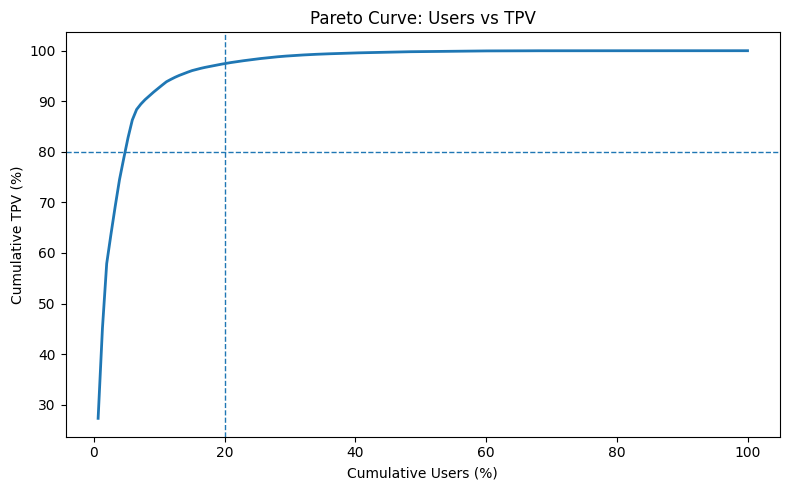

In [161]:
# Pareto curve

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    pareto['cum_users_pct'],
    pareto['cum_tpv_pct'],
    linewidth=2
)

ax.axvline(20, linestyle='--', linewidth=1)
ax.axhline(80, linestyle='--', linewidth=1)

ax.set_title('Pareto Curve: Users vs TPV')
ax.set_xlabel('Cumulative Users (%)')
ax.set_ylabel('Cumulative TPV (%)')

plt.tight_layout()
plt.show()

Top 20% users drive 97.51% of TPV, so the answer to the 80/20 question is yes. Just a small group of users drive almost all of the payments, so retaining this high frequency users is mandatory.

In [162]:
# 7.2  RFM scoring

SNAPSHOT_DATE = df['createdat_ts'].max()

rfm = (
    df[df['is_executed']]
    .groupby('user_id')
    .agg(
        last_payment=('createdat_ts','max'),
        frequency=('id','count'),
        monetary=('amount_in_currency','sum')
    )
    .reset_index()
)

rfm['recency_days'] = (SNAPSHOT_DATE - rfm['last_payment']).dt.days

print('RFM base stats:')
print(rfm[['recency_days','frequency','monetary']].describe().round(1))

RFM base stats:
       recency_days  frequency     monetary
count        153.00     153.00       153.00
mean         225.00   2,468.10    67,592.40
std          372.40   9,881.40   303,465.20
min            0.00       1.00         0.00
25%            0.00       4.00        55.80
50%           29.00      32.00     1,368.90
75%          313.00     444.00     9,901.30
max        1,648.00 102,222.00 2,822,439.60


In [163]:
# Score each dimension 1–5 using quintiles

def quintile_score(series, ascending=True):
    labels = [5,4,3,2,1] if ascending else [1,2,3,4,5]
    return pd.qcut(
        series.rank(method='first'),
        q=5,
        labels=labels
    ).astype(int)

rfm['R'] = quintile_score(rfm['recency_days'], ascending=True)   # lower recency → better → score 5
rfm['F'] = quintile_score(rfm['frequency'], ascending=False)
rfm['M'] = quintile_score(rfm['monetary'], ascending=False)

rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_total'] = rfm['R'] + rfm['F'] + rfm['M']

def rfm_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4: return 'Champions'
    if r >= 3 and f >= 3:            return 'Loyal'
    if r >= 4 and f <= 2:            return 'Promising'
    if r <= 2 and f >= 3:            return 'At Risk'
    if r <= 2 and f <= 2 and m >= 3: return 'Needs Attention'
    if r == 1 and f == 1:            return 'Lost'
    return 'Hibernating'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

print(rfm['segment'].value_counts())

segment
Champions          40
Hibernating        36
Loyal              31
At Risk            21
Lost               17
Promising           5
Needs Attention     3
Name: count, dtype: int64


In [164]:
# Segment summary table

seg_summary = (
    rfm.groupby('segment')
    .agg(
        users=('user_id','count'),
        avg_recency=('recency_days','mean'),
        avg_frequency=('frequency','mean'),
        avg_monetary=('monetary','mean'),
        total_tpv=('monetary','sum')
    )
    .round(1)
    .sort_values('total_tpv', ascending=False)
)

print(seg_summary.to_string())

                 users  avg_recency  avg_frequency  avg_monetary    total_tpv
segment                                                                      
Champions           40         0.40       9,214.00    242,097.20 9,683,889.80
At Risk             21       437.90         185.50     20,838.60   437,610.20
Loyal               31        11.40         157.30      6,685.70   207,258.20
Hibernating         36       204.30           5.20        226.50     8,154.40
Promising            5         1.40           8.60        487.10     2,435.60
Needs Attention      3       579.70          11.00        696.10     2,088.40
Lost                17       927.40           1.20         11.50       194.70


#### Q7.2 Answer

Recency is based on days since the user’s last executed payment, frequency is the number of executed payments, and monetary value is total executed TPV.

The strongest segment `Champions': 40 users generate 9.68 million TPV, being the largest segment by value and these users are very recent, very frequent, and high value.

The `At Risk` segment has 21 users and 437.6k TPV, but average recency is 437.9 days, meaning these users used to be valuable but have not paid recently.

The `Lost` and `Needs Attention` segments have much lower total TPV, but they show users who are either inactive or slipping away. The main business priority should be retaining Champions and trying to reactivate At Risk users.

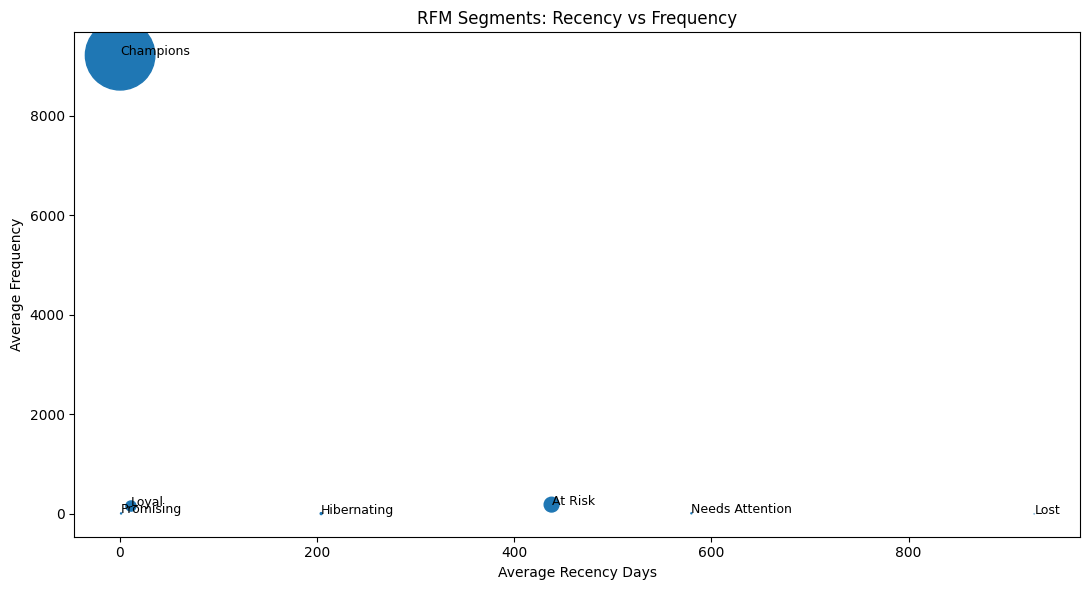

In [165]:
# 7.3  Bubble chart by RFM segment

seg_plot = seg_summary.reset_index().copy()

fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(
    seg_plot['avg_recency'],
    seg_plot['avg_frequency'],
    s=seg_plot['total_tpv'] / seg_plot['total_tpv'].max() * 2500,
    alpha=1
)

for _, row in seg_plot.iterrows():
    ax.text(
        row['avg_recency'],
        row['avg_frequency'],
        row['segment'],
        fontsize=9
    )

ax.set_title('RFM Segments: Recency vs Frequency')
ax.set_xlabel('Average Recency Days')
ax.set_ylabel('Average Frequency')

plt.tight_layout()
plt.show()

In [166]:
# 7.4  RFM segment by vertical

user_vertical = (
    df[df['is_executed']]
    .groupby(['user_id', 'vertical'])
    .agg(payments=('id','count'))
    .reset_index()
)

user_vertical = (
    user_vertical
    .sort_values(['user_id', 'payments'], ascending=[True, False])
    .drop_duplicates('user_id')
)

rfm_vertical = rfm.merge(
    user_vertical[['user_id','vertical']],
    on='user_id',
    how='left'
)

segment_vertical = pd.crosstab(
    rfm_vertical['segment'],
    rfm_vertical['vertical'],
    normalize='index'
).round(3)

print(segment_vertical.to_string())

vertical         vertical 1  vertical 2  vertical 3  vertical 4  vertical 5
segment                                                                    
At Risk                0.00        0.48        0.14        0.14        0.24
Champions              0.03        0.55        0.00        0.05        0.38
Hibernating            0.14        0.54        0.06        0.14        0.11
Lost                   0.27        0.53        0.07        0.13        0.00
Loyal                  0.03        0.58        0.07        0.13        0.19
Needs Attention        0.33        0.67        0.00        0.00        0.00
Promising              0.20        0.40        0.00        0.40        0.00


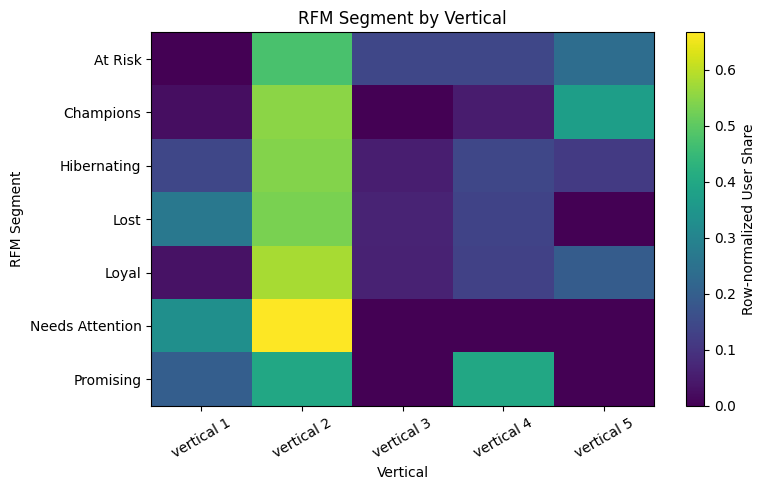

In [167]:
# Heatmap-style plot using matplotlib

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(segment_vertical, aspect='auto')

ax.set_title('RFM Segment by Vertical')
ax.set_xlabel('Vertical')
ax.set_ylabel('RFM Segment')

ax.set_xticks(range(len(segment_vertical.columns)))
ax.set_xticklabels(segment_vertical.columns, rotation=30)

ax.set_yticks(range(len(segment_vertical.index)))
ax.set_yticklabels(segment_vertical.index)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Row-normalized User Share')

plt.tight_layout()
plt.show()

#### Q7.3–Q7.4 Answer

The RFM bubble chart shows that the `Champions` segment is very different from the rest of the user base. Champions have very low average recency, extremely high average frequency, and the largest total TPV. This is why their bubble dominates the chart.

Other segments sit much lower on the frequency axis. `At Risk` users still have meaningful total TPV, but their average recency is much higher, meaning they have not been active recently. `Lost`, `Hibernating`, and `Needs Attention` users have lower frequency and lower total value.

The vertical heatmap is row-normalized, so each row shows how users within that RFM segment are distributed across verticals. Vertical 2 is the largest vertical across most segments. For example, 55% of Champions and 58% of Loyal users are mainly associated with vertical 2. Champions are also strongly represented in vertical 5, with 38% of Champion users assigned to that vertical.

Overall, the main business message is that high-value users are concentrated in a small number of RFM segments and mostly in vertical 2 and vertical 5. Retention work should focus first on Champions and At Risk users, especially within these major verticals.

In [168]:
# ============================================================
# Section 8 — Retention & Growth Accounting
# ============================================================

# 8.1  Build event-level 90-day forward retention table

from datetime import timedelta

SNAPSHOT    = df['createdat_ts'].max()
WINDOW_DAYS = 90

events = df[df['is_executed']][['user_id','createdat_ts','created_month','vertical']].copy()
events = events.rename(columns={'createdat_ts':'payment_date'})
events = events.sort_values(['user_id','payment_date'])

events['next_payment'] = events.groupby('user_id')['payment_date'].shift(-1)
events['window_end']   = events['payment_date'] + timedelta(days=WINDOW_DAYS)
events['censored']     = events['window_end'] > SNAPSHOT

events['retained'] = (
    events['next_payment'].notna() &
    (events['next_payment'] <= events['window_end'])
)

eligible = events[~events['censored']]
rate = eligible['retained'].sum() / len(eligible) * 100

print(f'Total events       : {len(events):,}')
print(f'Censored           : {events["censored"].sum():,}')
print(f'Eligible           : {len(eligible):,}')
print(f'Retained           : {int(eligible["retained"].sum()):,}')
print(f'90-Day Retention   : {rate:.2f}%')

Total events       : 377,616
Censored           : 78,040
Eligible           : 299,576
Retained           : 299,446
90-Day Retention   : 99.96%


In [169]:
# 8.1  Monthly retention rate trend

events['month'] = events['payment_date'].dt.to_period('M')

monthly_ret = (
    events[~events['censored']]
    .groupby('month')
    .agg(
        eligible=('user_id','count'),
        retained=('retained','sum')
    )
    .reset_index()
)

monthly_ret['retention_rate'] = (
    monthly_ret['retained'] / monthly_ret['eligible'] * 100
).round(2)

monthly_ret['month_str'] = monthly_ret['month'].astype(str)

print(monthly_ret.head().to_string(index=False))
print()
print(monthly_ret.tail().to_string(index=False))

  month  eligible  retained  retention_rate month_str
2005-05         1         1          100.00   2005-05
2005-07        35        35          100.00   2005-07
2005-08        50        48           96.00   2005-08
2005-09        96        96          100.00   2005-09
2005-10       165       165          100.00   2005-10

  month  eligible  retained  retention_rate month_str
2009-07     16612     16609           99.98   2009-07
2009-08     20461     20454           99.97   2009-08
2009-09     20728     20726           99.99   2009-09
2009-10     21324     21321           99.99   2009-10
2009-11      9184      9181           99.97   2009-11


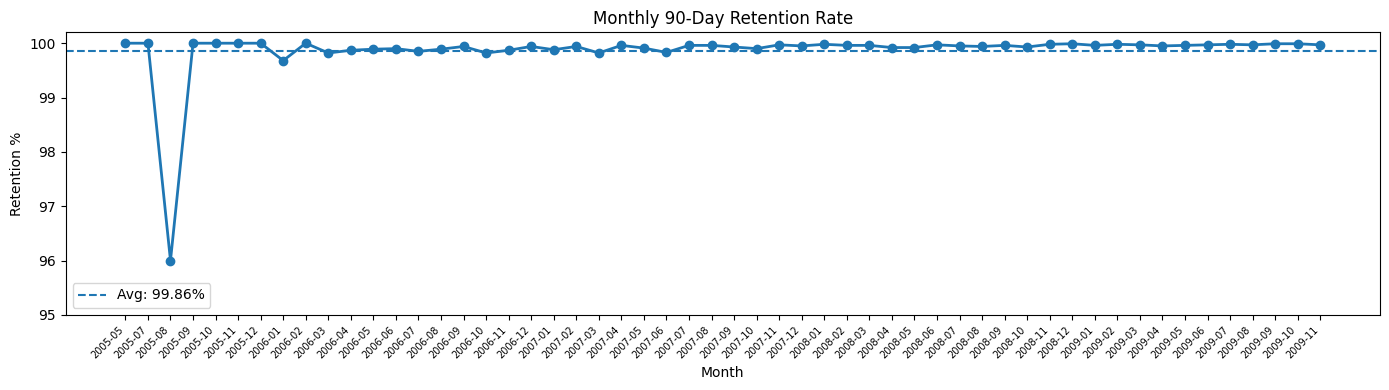

In [170]:
# 8.1  Plot monthly 90-day retention rate

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    monthly_ret['month_str'],
    monthly_ret['retention_rate'],
    marker='o',
    linewidth=2
)

ax.axhline(
    monthly_ret['retention_rate'].mean(),
    linestyle='--',
    label=f"Avg: {monthly_ret['retention_rate'].mean():.2f}%"
)

ax.set_title('Monthly 90-Day Retention Rate')
ax.set_xlabel('Month')
ax.set_ylabel('Retention %')
ax.set_ylim(95, 100.2)
ax.legend()

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

In [171]:
# 8.1  90-day retention by vertical

vertical_ret = (
    events[~events['censored']]
    .groupby('vertical', dropna=False)
    .agg(
        eligible=('user_id','count'),
        retained=('retained','sum')
    )
    .reset_index()
)

vertical_ret['retention_rate'] = (
    vertical_ret['retained'] / vertical_ret['eligible'] * 100
).round(2)

vertical_ret = vertical_ret.sort_values('retention_rate', ascending=False)

print(vertical_ret.to_string(index=False))

  vertical  eligible  retained  retention_rate
vertical 5     80850     80835           99.98
vertical 2    210927    210855           99.97
vertical 4      7252      7237           99.79
vertical 3       268       259           96.64
vertical 1       277       260           93.86
       NaN         2         0            0.00


#### Q8.1 Answer

The 90-day forward retention rate is very high. Out of 299,576 eligible executed payment events, 299,446 had another executed payment within the next 90 days, giving a 90-day retention rate of 99.96%.

The monthly trend is also stable. Most months are close to 100%, so the chart uses a zoomed y-axis to make the small differences easier to see. Without zooming, the line would look almost completely flat because the values are all near the top of the 0–100% range.

Retention is also high across the main verticals. Vertical 5, vertical 2, and vertical 4 are all above 99%, while vertical 3 and vertical 1 are lower but still high. The row with missing vertical should not be interpreted strongly because it has only 2 eligible payments.

In [172]:
# 8.2  Build cohort retention table

user_months = (
    df[df['is_executed']]
    .assign(month=lambda x: x['createdat_ts'].dt.to_period('M'))
    .groupby(['user_id','month'])
    .size()
    .reset_index(name='payments')
)

first_month = user_months.groupby('user_id')['month'].min().rename('cohort_month')
user_months = user_months.join(first_month, on='user_id')

user_months['period_number'] = (
    (user_months['month'].dt.year - user_months['cohort_month'].dt.year) * 12 +
    (user_months['month'].dt.month - user_months['cohort_month'].dt.month)
)

cohort_counts = (
    user_months[user_months['period_number'].between(0, 12)]
    .groupby(['cohort_month','period_number'])
    .agg(users=('user_id','nunique'))
    .reset_index()
)

cohort_sizes = (
    cohort_counts[cohort_counts['period_number'] == 0]
    [['cohort_month','users']]
    .rename(columns={'users':'cohort_size'})
)

cohort_counts = cohort_counts.merge(
    cohort_sizes,
    on='cohort_month',
    how='left'
)

cohort_counts['retention_rate'] = (
    cohort_counts['users'] / cohort_counts['cohort_size'] * 100
).round(2)

print(cohort_counts.head(20).to_string(index=False))

cohort_month  period_number  users  cohort_size  retention_rate
     2005-05              0      1            1          100.00
     2005-05              3      1            1          100.00
     2005-05              4      1            1          100.00
     2005-05              5      1            1          100.00
     2005-05              6      1            1          100.00
     2005-05              7      1            1          100.00
     2005-05              8      1            1          100.00
     2005-05              9      1            1          100.00
     2005-05             10      1            1          100.00
     2005-05             11      1            1          100.00
     2005-05             12      1            1          100.00
     2005-07              0      1            1          100.00
     2005-07              1      1            1          100.00
     2005-07              2      1            1          100.00
     2005-07              3      1      

In [173]:
# 8.2  Cohort retention matrix, months +1 to +12

cohort_matrix = cohort_counts.pivot_table(
    index='cohort_month',
    columns='period_number',
    values='retention_rate'
)

cohort_matrix_12 = cohort_matrix.loc[:, cohort_matrix.columns.isin(range(1, 13))].copy()

print(cohort_matrix_12.head(20).to_string())

period_number     1      2      3      4      5      6      7      8      9      10     11     12
cohort_month                                                                                     
2005-05          NaN    NaN 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00
2005-07       100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00
2005-08        33.33  33.33  33.33  33.33  33.33  33.33  33.33  33.33  33.33  33.33  33.33  33.33
2006-01        50.00  75.00  50.00  75.00  50.00  75.00  75.00 100.00  75.00  50.00  50.00  50.00
2006-02       100.00  50.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00
2006-03        40.00  60.00  40.00  40.00  60.00  60.00  80.00  40.00  60.00  60.00  40.00  40.00
2006-04        75.00  75.00  75.00  50.00  50.00  50.00  50.00  50.00  50.00  50.00  75.00  50.00
2006-05          NaN 100.00    NaN    NaN    NaN    NaN    NaN    NaN    NaN 100.00 100.00 100.00
2006-06          NaN

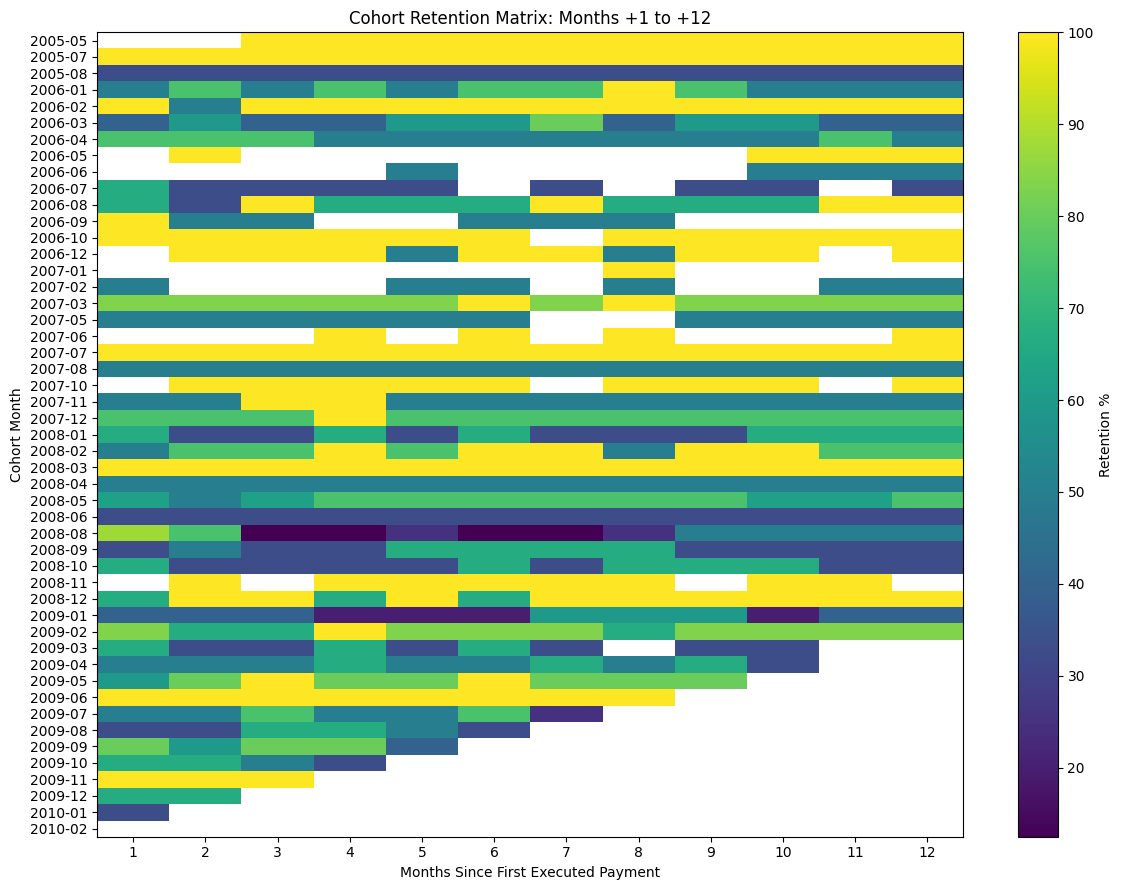

In [174]:
# 8.2  Plot cohort retention heatmap

fig, ax = plt.subplots(figsize=(12, 9))

cohort_plot = np.ma.masked_invalid(cohort_matrix_12.values)

im = ax.imshow(
    cohort_plot,
    aspect='auto'
)

ax.set_title('Cohort Retention Matrix: Months +1 to +12')
ax.set_xlabel('Months Since First Executed Payment')
ax.set_ylabel('Cohort Month')

ax.set_xticks(range(len(cohort_matrix_12.columns)))
ax.set_xticklabels(cohort_matrix_12.columns)

ax.set_yticks(range(len(cohort_matrix_12.index)))
ax.set_yticklabels(cohort_matrix_12.index.astype(str))

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Retention %')

plt.tight_layout()
plt.show()

In [175]:
# 8.2  Best 3-month retention cohort

month_3 = (
    cohort_counts[cohort_counts['period_number'] == 3]
    .sort_values(['retention_rate','cohort_size'], ascending=[False, False])
    .copy()
)

print('Top cohorts by month-3 retention:')
print(
    month_3[
        ['cohort_month','users','cohort_size','retention_rate']
    ]
    .head(10)
    .to_string(index=False)
)

print()
print('Best 3-month retention cohort:')
print(
    month_3[
        ['cohort_month','retention_rate','cohort_size']
    ]
    .head(1)
    .to_string(index=False)
)

Top cohorts by month-3 retention:
cohort_month  users  cohort_size  retention_rate
     2009-05      5            5          100.00
     2006-08      3            3          100.00
     2008-12      3            3          100.00
     2006-02      2            2          100.00
     2006-12      2            2          100.00
     2007-11      2            2          100.00
     2005-05      1            1          100.00
     2005-07      1            1          100.00
     2006-10      1            1          100.00
     2007-07      1            1          100.00

Best 3-month retention cohort:
cohort_month  retention_rate  cohort_size
     2009-05          100.00            5


#### Q8.2 Answer

The cohort retention matrix tracks users from the month of their first executed payment and follows whether they remain active in later months. Each row is a cohort and columns show the number of months since that cohort's first successful payment.

The matrix shows us an overall high retention with many cohorts reaching 100% in several periods. but we do need to interpret carefully because many cohorts are very small. In small cohorts, one user can move the retention rate a lot, so a 100% value does not always mean that its a strong patternn.

The main takeaway is that retention looks strong overall, but the cohort matrix is better used as supporting evidence than the main business conclusion.

In [176]:
# 8.3  Build monthly growth accounting table

user_months = (
    df[df['is_executed']]
    .assign(month=lambda x: x['createdat_ts'].dt.to_period('M'))
    .groupby(['user_id','month'])
    .size()
    .reset_index(name='payments')
)

first_month = user_months.groupby('user_id')['month'].min().rename('first_month')
user_months = user_months.join(first_month, on='user_id')

all_months = sorted(user_months['month'].unique())
result = []

for i, month in enumerate(all_months):
    curr_users = set(user_months[user_months['month'] == month]['user_id'])
    prev_users = set(user_months[user_months['month'] == all_months[i-1]]['user_id']) if i > 0 else set()

    new_users   = {u for u in curr_users if first_month[u] == month}
    retained    = curr_users & prev_users - new_users
    resurrected = curr_users - prev_users - new_users
    churned     = prev_users - curr_users

    result.append({
        'month': str(month),
        'MAU': len(curr_users),
        'new': len(new_users),
        'retained': len(retained),
        'resurrected': len(resurrected),
        'churned': len(churned),
        'net_change': len(new_users) + len(resurrected) - len(churned)
    })

growth = pd.DataFrame(result)

print(growth.to_string(index=False))

  month  MAU  new  retained  resurrected  churned  net_change
2005-05    1    1         0            0        0           1
2005-07    1    1         0            0        1           0
2005-08    5    3         1            1        0           4
2005-09    3    0         3            0        2          -2
2005-10    3    0         3            0        0           0
2005-11    3    0         3            0        0           0
2005-12    3    0         3            0        0           0
2006-01    7    4         3            0        0           4
2006-02    7    2         5            0        2           0
2006-03   13    5         7            1        0           6
2006-04   12    4         8            0        5          -1
2006-05   15    1        10            4        2           3
2006-06   14    2        12            0        3          -1
2006-07   17    3        11            3        3           3
2006-08   18    3        13            2        4           1
2006-09 

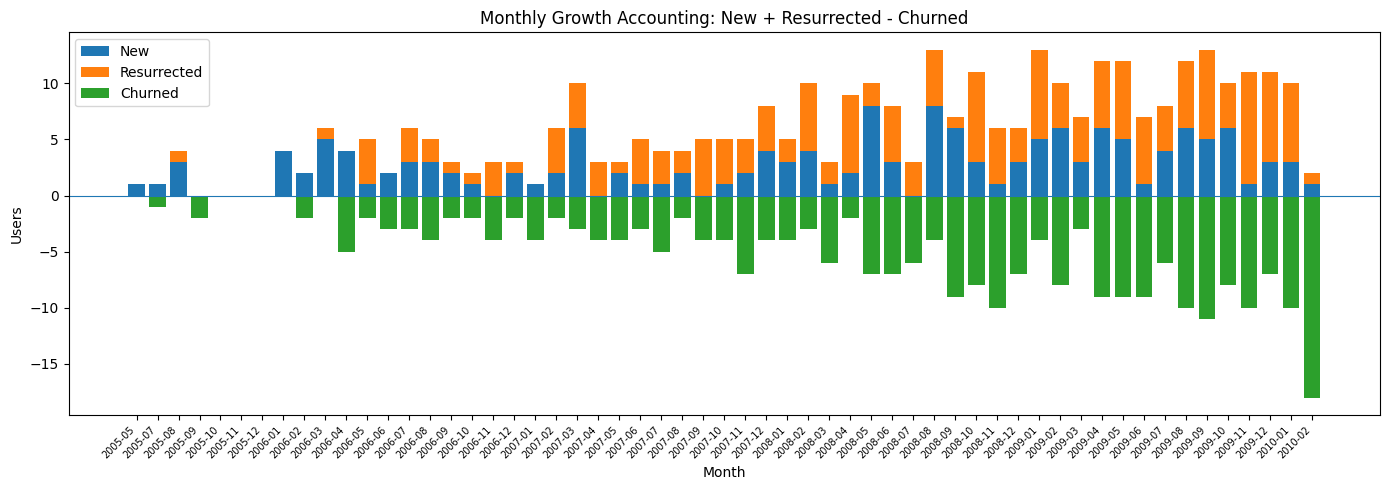

In [177]:
# 8.3  Growth accounting waterfall chart

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    growth['month'],
    growth['new'],
    label='New'
)

ax.bar(
    growth['month'],
    growth['resurrected'],
    bottom=growth['new'],
    label='Resurrected'
)

ax.bar(
    growth['month'],
    -growth['churned'],
    label='Churned'
)

ax.axhline(0, linewidth=0.8)

ax.set_title('Monthly Growth Accounting: New + Resurrected - Churned')
ax.set_xlabel('Month')
ax.set_ylabel('Users')
ax.legend()

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

In [178]:
# 8.3  Last 6 months growth check

last_6_growth = growth.tail(6).copy()

print('Last 6 months:')
print(last_6_growth.to_string(index=False))

print()
print(f'Net change in last 6 months: {last_6_growth["net_change"].sum():,.0f}')

if last_6_growth['net_change'].sum() > 0:
    print('User base is growing in the last 6 months.')
elif last_6_growth['net_change'].sum() < 0:
    print('User base is contracting in the last 6 months.')
else:
    print('User base is flat in the last 6 months.')

Last 6 months:
  month  MAU  new  retained  resurrected  churned  net_change
2009-09   75    5        62            8       11           2
2009-10   77    6        67            4        8           2
2009-11   78    1        67           10       10           1
2009-12   82    3        71            8        7           4
2010-01   82    3        72            7       10           0
2010-02   66    1        64            1       18         -16

Net change in last 6 months: -7
User base is contracting in the last 6 months.


#### Q8.3 Answer

The growth accounting table breaks monthly active users into new, retained, resurrected, and churned users. This makes the MAU trend easier to understand because we can see whether growth is coming from new acquisition, returning users, or existing users staying active.

The main driver of the user base is retained users. By the end of the period, retained users make up most monthly active users: for example, 2010-01 had 82 MAU, with 72 retained users. New users are much smaller, usually only a few users per month, while resurrected users add some extra activity but do not drive the trend on their own.

The last 6 months show a net change of -7 users. Most of this comes from 2010-02, where MAU dropped from 82 to 66 and churn increased to 18 users. This suggests a recent slowdown or contraction after a long period of growth. However, 2010-02 should be interpreted carefully because it may be a partial month at the end of the dataset.

Overall, the user base looks sticky because retention is strong, but growth is not mainly coming from new users. The business depends heavily on keeping existing active users engaged, and the latest months show that churn can quickly offset new and resurrected users.